<a href="https://colab.research.google.com/" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Predicting Sleep Quality and Disorders Using LSTM Models on Wearable Sensor Data**


**Dataset:** [Sleep Health and Lifestyle Dataset](https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset)
— 374 records × 13 features capturing wearable-style physiological and lifestyle measurements,
with a 3-class sleep disorder label.





In [ ]:
! pip install kaggle -q
! mkdir ~/.kaggle                         
! cp kaggle.json ~/.kaggle/               
! chmod 600 ~/.kaggle/kaggle.json         


In [ ]:
! kaggle datasets download -d uom190346a/sleep-health-and-lifestyle-dataset  


Dataset URL: https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset
License(s): CC0-1.0
  0% 0.00/2.54k [00:00<?, ?B/s]
100% 2.54k/2.54k [00:00<00:00, 9.24MB/s]


In [ ]:
! unzip -q sleep-health-and-lifestyle-dataset.zip  
! ls *.csv


Sleep_health_and_lifestyle_dataset.csv


# Importing Necessary Libraries
<hr>


In [ ]:
import warnings, os
warnings.filterwarnings('ignore')

import numpy as np                        
import pandas as pd                       
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, BatchNormalization, Bidirectional,
    GRU, Conv1D, MaxPooling1D, Flatten, GlobalAveragePooling1D,
    Input, Add, Multiply, Attention, LayerNormalization,
    MultiHeadAttention, Reshape
)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import model_from_json

# Imbalance
from imblearn.over_sampling import SMOTE

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPU available: []


In [ ]:
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')  


df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')  
df = df.reset_index(drop=True)

print(f"Dataset shape after cleaning: {df.shape}")
df.head(5), df.shape     


Dataset shape after cleaning: (374, 13)


(   Person ID Gender  Age            Occupation  Sleep Duration  \
 0          1   Male   27     Software Engineer             6.1   
 1          2   Male   28                Doctor             6.2   
 2          3   Male   28                Doctor             6.2   
 3          4   Male   28  Sales Representative             5.9   
 4          5   Male   28  Sales Representative             5.9   
 
    Quality of Sleep  Physical Activity Level  Stress Level BMI Category  \
 0                 6                       42             6   Overweight   
 1                 6                       60             8       Normal   
 2                 6                       60             8       Normal   
 3                 4                       30             8        Obese   
 4                 4                       30             8        Obese   
 
   Blood Pressure  Heart Rate  Daily Steps Sleep Disorder  
 0         126/83          77         4200           None  
 1         125/80 

## **Exploratory Data Analysis**



In [ ]:
print("Null values present in the file:", df.isna().sum().sum())
print("\nBasic information about the dataframe:")
df.info()

df.describe()


Null values present in the file: 0

Basic information about the dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           374 non-null    object 
dtypes: fl

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [ ]:

sleep_disorders = {     
    0: 'Insomnia',
    1: 'None',
    2: 'Sleep Apnea'
}
print("Sleep disorder classes:", sleep_disorders)
print("\nUnique values in Sleep Disorder column (NaN-safe):")
print(df['Sleep Disorder'].value_counts(dropna=False))


Sleep disorder classes: {0: 'Insomnia', 1: 'None', 2: 'Sleep Apnea'}

Unique values in Sleep Disorder column (NaN-safe):
Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


## Number of records present in dataset corresponding to each sleep disorder

In [ ]:
count_disorders = df['Sleep Disorder'].value_counts().to_frame()
count_disorders.columns = ['count']
count_disorders['disorder name'] = count_disorders.index
count_disorders


,count,disorder name
Sleep Disorder,,
None,219,None
Sleep Apnea,78,Sleep Apnea
Insomnia,77,Insomnia


## Distribution of records by Gender and BMI Category

In [ ]:
count_gender = df.groupby('Gender')['Sleep Disorder'].count().to_frame()
count_gender.columns = ['count']

count_bmi = df.groupby('BMI Category')['Sleep Disorder'].count().to_frame()
count_bmi.columns = ['count']

print("By Gender:")
print(count_gender)
print("\nBy BMI Category:")
print(count_bmi)


By Gender:
        count
Gender       
Female    185
Male      189

By BMI Category:
               count
BMI Category        
Normal           195
Normal Weight     21
Obese             10
Overweight       148


## Sleep Disorder Class Distribution (Bar Chart)



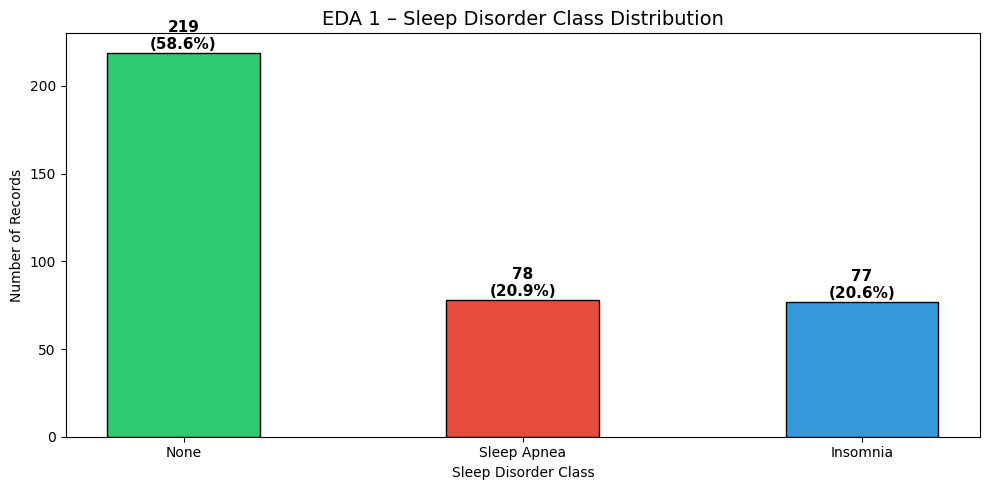

Class counts:
Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77


In [ ]:

import matplotlib.pyplot as plt, numpy as np

disorder_counts = df['Sleep Disorder'].value_counts()
colors_eda1 = ['#2ecc71', '#e74c3c', '#3498db']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(disorder_counts.index, disorder_counts.values,
              color=colors_eda1, edgecolor='black', width=0.45)
for bar, cnt in zip(bars, disorder_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{cnt}\n({cnt/len(df)*100:.1f}%)',
            ha='center', fontsize=11, fontweight='bold')
ax.set_title('EDA 1 – Sleep Disorder Class Distribution', fontsize=14)
ax.set_xlabel('Sleep Disorder Class'); ax.set_ylabel('Number of Records')
plt.tight_layout(); plt.show()
print("Class counts:")
print(disorder_counts.to_string())


##  Gender & BMI Category Distribution (Pie Charts)



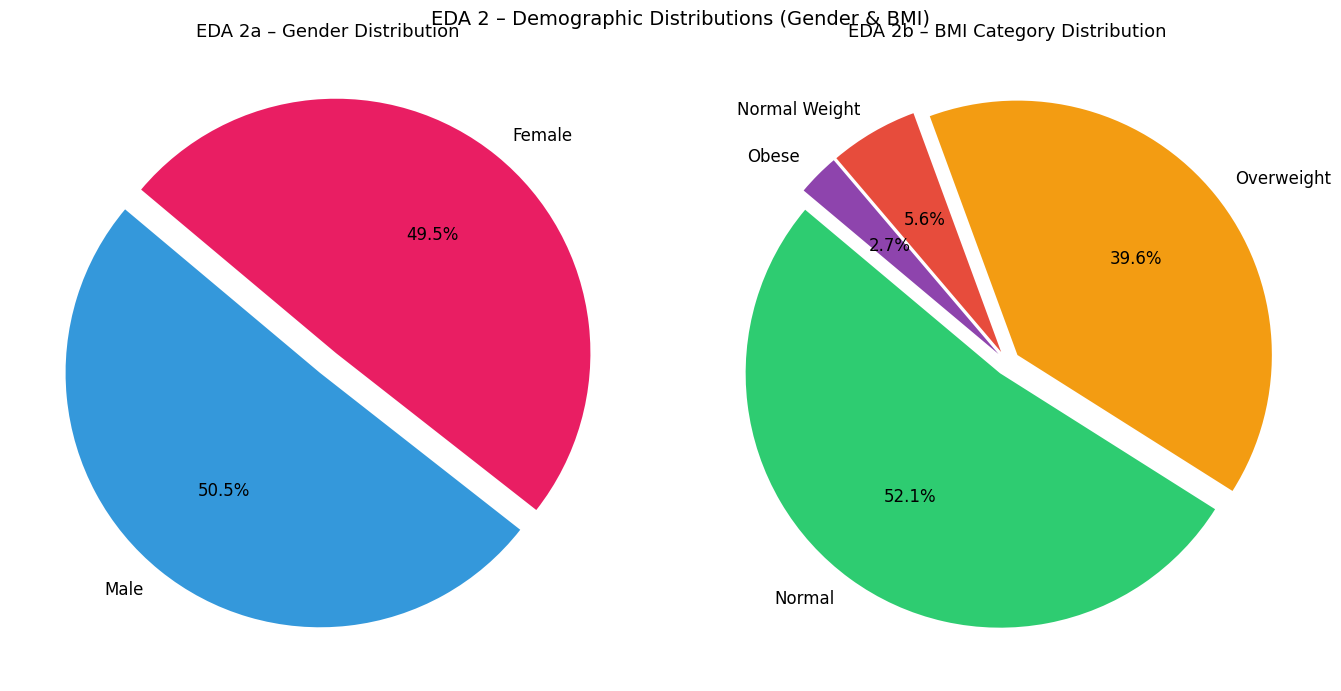

Gender
Male      189
Female    185
Name: count, dtype: int64

 BMI Category
Normal           195
Overweight       148
Normal Weight     21
Obese             10
Name: count, dtype: int64


In [ ]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Gender
gender_counts = df['Gender'].value_counts()
axes[0].pie(gender_counts.values, labels=gender_counts.index,
            autopct='%1.1f%%', colors=['#3498db','#e91e63'],
            explode=[0.05]*len(gender_counts), startangle=140,
            textprops={'fontsize': 12})
axes[0].set_title('EDA 2a – Gender Distribution', fontsize=13)

# BMI Category
bmi_counts = df['BMI Category'].value_counts()
colors_bmi = ['#2ecc71','#f39c12','#e74c3c','#8e44ad']
axes[1].pie(bmi_counts.values, labels=bmi_counts.index,
            autopct='%1.1f%%', colors=colors_bmi[:len(bmi_counts)],
            explode=[0.05]*len(bmi_counts), startangle=140,
            textprops={'fontsize': 12})
axes[1].set_title('EDA 2b – BMI Category Distribution', fontsize=13)

plt.suptitle('EDA 2 – Demographic Distributions (Gender & BMI)', fontsize=14)
plt.tight_layout(); plt.show()
print(gender_counts); print("\n", bmi_counts)


## Sleep Disorder Frequency per Occupation (Grouped Bar)



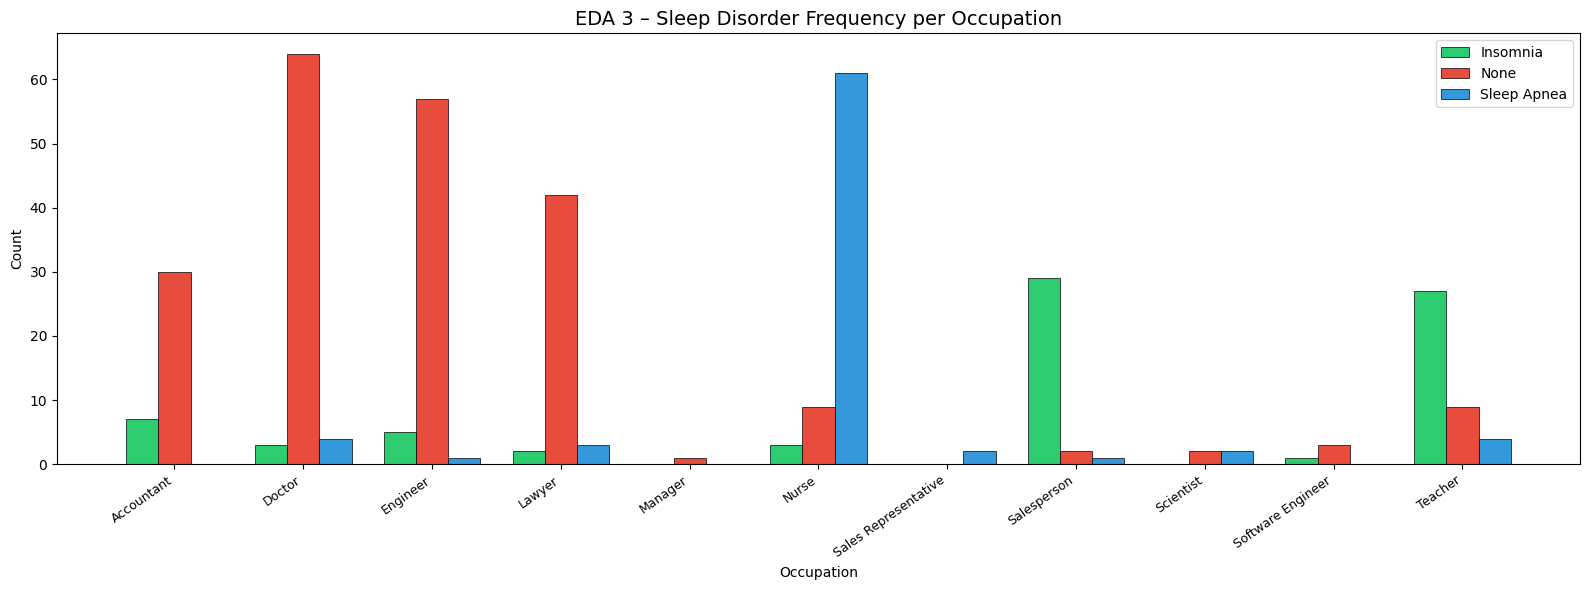

In [ ]:

import matplotlib.pyplot as plt, numpy as np


df_eda3 = df.dropna(subset=['Sleep Disorder', 'Occupation']).copy()

disorder_occ     = df_eda3.groupby(['Occupation', 'Sleep Disorder']).size().unstack(fill_value=0)
disorder_classes = disorder_occ.columns.tolist()
x     = np.arange(len(disorder_occ))
width = 0.25
colors_occ = ['#2ecc71', '#e74c3c', '#3498db']

fig, ax = plt.subplots(figsize=(16, 6))
for idx, (disorder, color) in enumerate(zip(disorder_classes, colors_occ)):
    ax.bar(x + idx*width, disorder_occ[disorder], width,
           label=disorder, color=color, edgecolor='black', linewidth=0.5)

ax.set_xticks(x + width)
ax.set_xticklabels(disorder_occ.index, rotation=35, ha='right', fontsize=9)
ax.set_title('EDA 3 – Sleep Disorder Frequency per Occupation', fontsize=14)
ax.set_xlabel('Occupation'); ax.set_ylabel('Count'); ax.legend()
plt.tight_layout(); plt.show()


## Wearable Sensor Feature Statistics per Sleep Disorder Class



EDA 4 – Sensor Feature Statistics per Sleep Disorder Class
   Disorder                 Feature     Mean      Std    Min     Max  Count
   Insomnia              Heart Rate   70.468    4.949   65.0    85.0     77
   Insomnia          Sleep Duration    6.590    0.387    5.9     8.3     77
   Insomnia Physical Activity Level   46.818   11.752   30.0    90.0     77
   Insomnia            Stress Level    5.870    1.463    3.0     8.0     77
   Insomnia             Daily Steps 5901.299 1000.328 3000.0 10000.0     77
       None              Heart Rate   69.018    2.658   65.0    77.0    219
       None          Sleep Duration    7.358    0.732    6.0     8.5    219
       None Physical Activity Level   57.950   20.930   30.0    90.0    219
       None            Stress Level    5.114    1.591    3.0     8.0    219
       None             Daily Steps 6852.968 1393.474 4200.0 10000.0    219
Sleep Apnea              Heart Rate   73.090    5.117   68.0    86.0     78
Sleep Apnea          Sleep Du

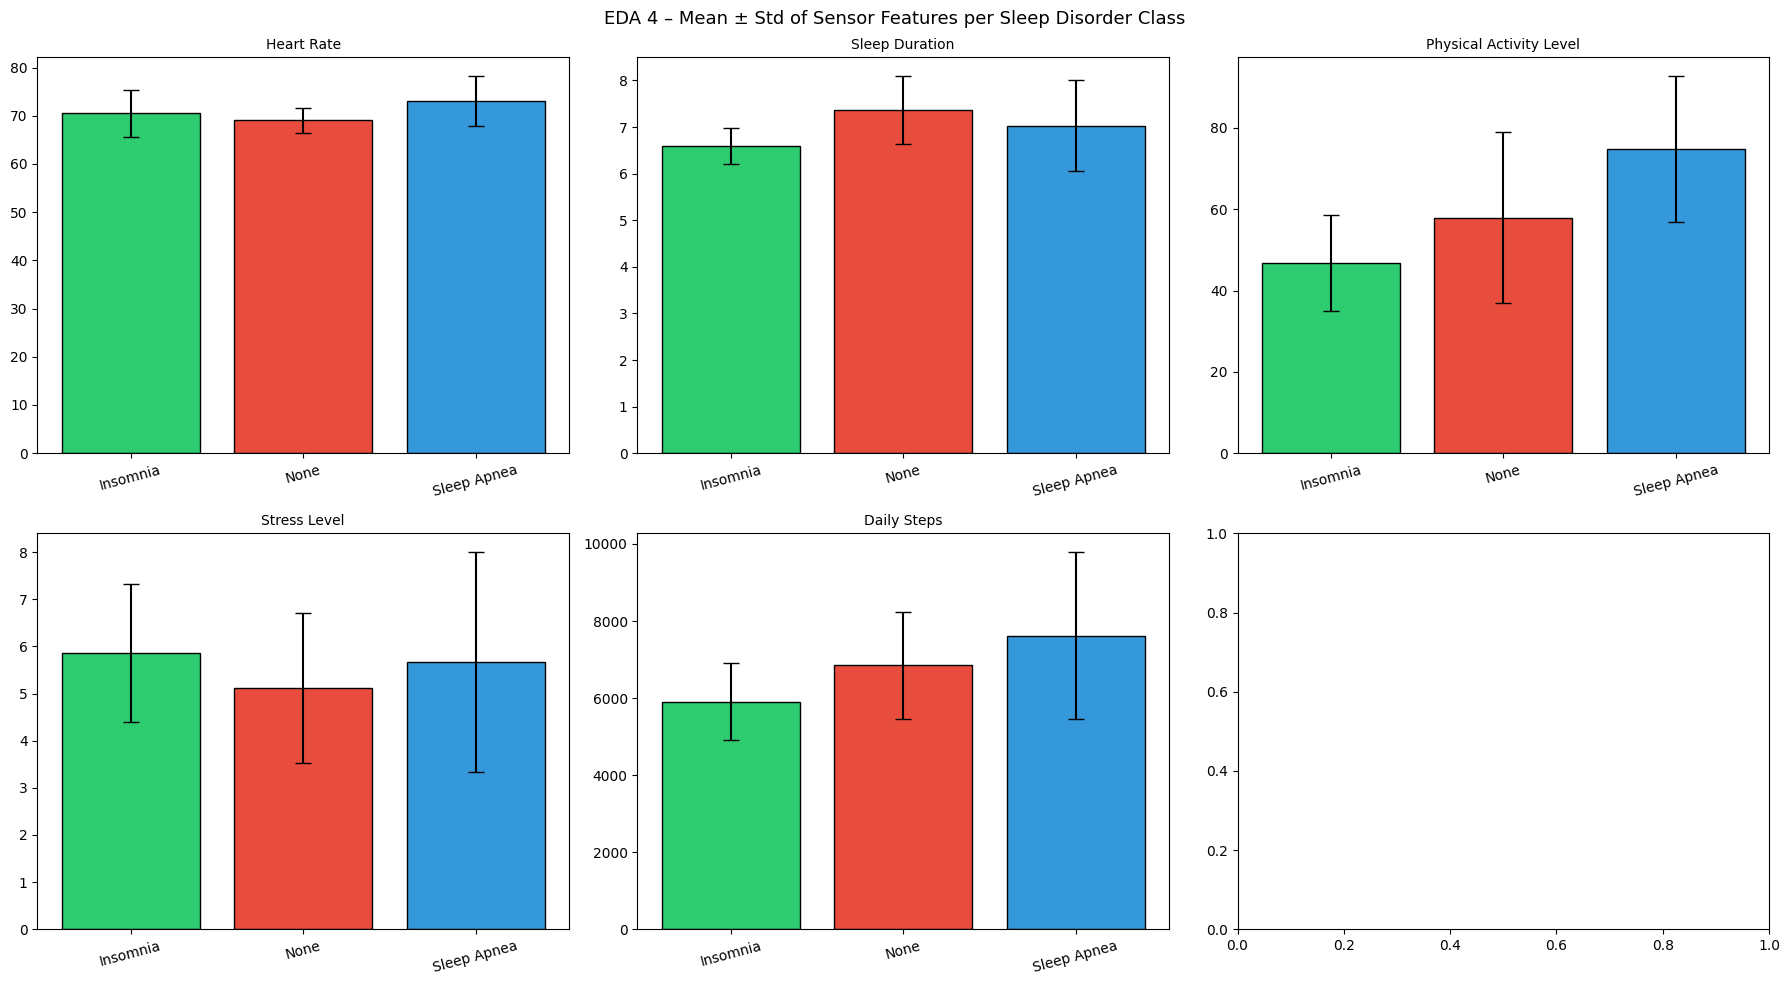

In [ ]:

import pandas as pd, numpy as np

sensor_feats = ['Heart Rate', 'Blood Oxygen Level', 'Sleep Duration',
                'Physical Activity Level', 'Stress Level', 'Daily Steps']


sensor_feats = [f for f in sensor_feats if f in df.columns]


df_eda4 = df.dropna(subset=['Sleep Disorder'] + sensor_feats).copy()


disorder_order = sorted(df_eda4['Sleep Disorder'].dropna().unique(), key=str)

rows = []
for disorder in disorder_order:
    sub = df_eda4[df_eda4['Sleep Disorder'] == disorder][sensor_feats]
    for feat in sensor_feats:
        rows.append({
            'Disorder': disorder,
            'Feature':  feat,
            'Mean':     round(sub[feat].mean(), 3),
            'Std':      round(sub[feat].std(),  3),
            'Min':      round(sub[feat].min(),  3),
            'Max':      round(sub[feat].max(),  3),
            'Count':    len(sub)
        })

stats_df = pd.DataFrame(rows)
print("EDA 4 – Sensor Feature Statistics per Sleep Disorder Class")
print(stats_df.to_string(index=False))


fig, axes = plt.subplots(2, 3, figsize=(18, 10))
colors_stat = ['#2ecc71', '#e74c3c', '#3498db']
for ax, feat in zip(axes.ravel(), sensor_feats):
    means = [df_eda4[df_eda4['Sleep Disorder']==d][feat].mean() for d in disorder_order]
    stds  = [df_eda4[df_eda4['Sleep Disorder']==d][feat].std()  for d in disorder_order]
    ax.bar(disorder_order, means, yerr=stds,
           color=colors_stat[:len(disorder_order)], edgecolor='black', capsize=6)
    ax.set_title(feat, fontsize=10)
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('EDA 4 – Mean ± Std of Sensor Features per Sleep Disorder Class', fontsize=13)
plt.tight_layout(); plt.show()


## Sample Count Heatmap (Sleep Disorder × Age Group)



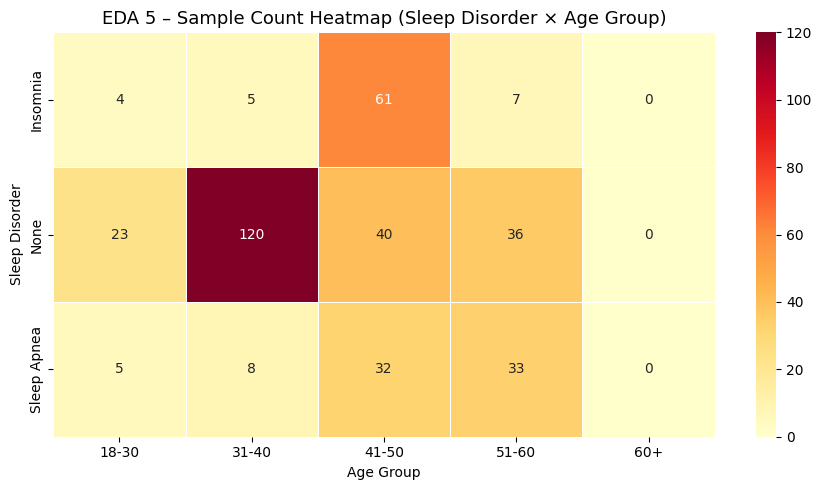

In [ ]:

import matplotlib.pyplot as plt, numpy as np, seaborn as sns

df_eda5 = df.dropna(subset=['Sleep Disorder', 'Age']).copy()

df_eda5['Age Group'] = pd.cut(df_eda5['Age'], bins=[18,30,40,50,60,90],
                               labels=['18-30','31-40','41-50','51-60','60+'])
age_groups    = ['18-30','31-40','41-50','51-60','60+']

# Safe sort — key=str avoids NaN comparison TypeError
disorder_list = sorted(df_eda5['Sleep Disorder'].dropna().unique(), key=str)

matrix = np.array([
    [df_eda5[(df_eda5['Sleep Disorder']==d) & (df_eda5['Age Group']==ag)].shape[0]
     for ag in age_groups]
    for d in disorder_list
])

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(matrix, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=age_groups, yticklabels=disorder_list,
            linewidths=0.5, ax=ax)
ax.set_title('EDA 5 – Sample Count Heatmap (Sleep Disorder × Age Group)', fontsize=13)
ax.set_xlabel('Age Group'); ax.set_ylabel('Sleep Disorder')
plt.tight_layout(); plt.show()


## Visualising Wearable Sensor Signal Samples from the Dataset

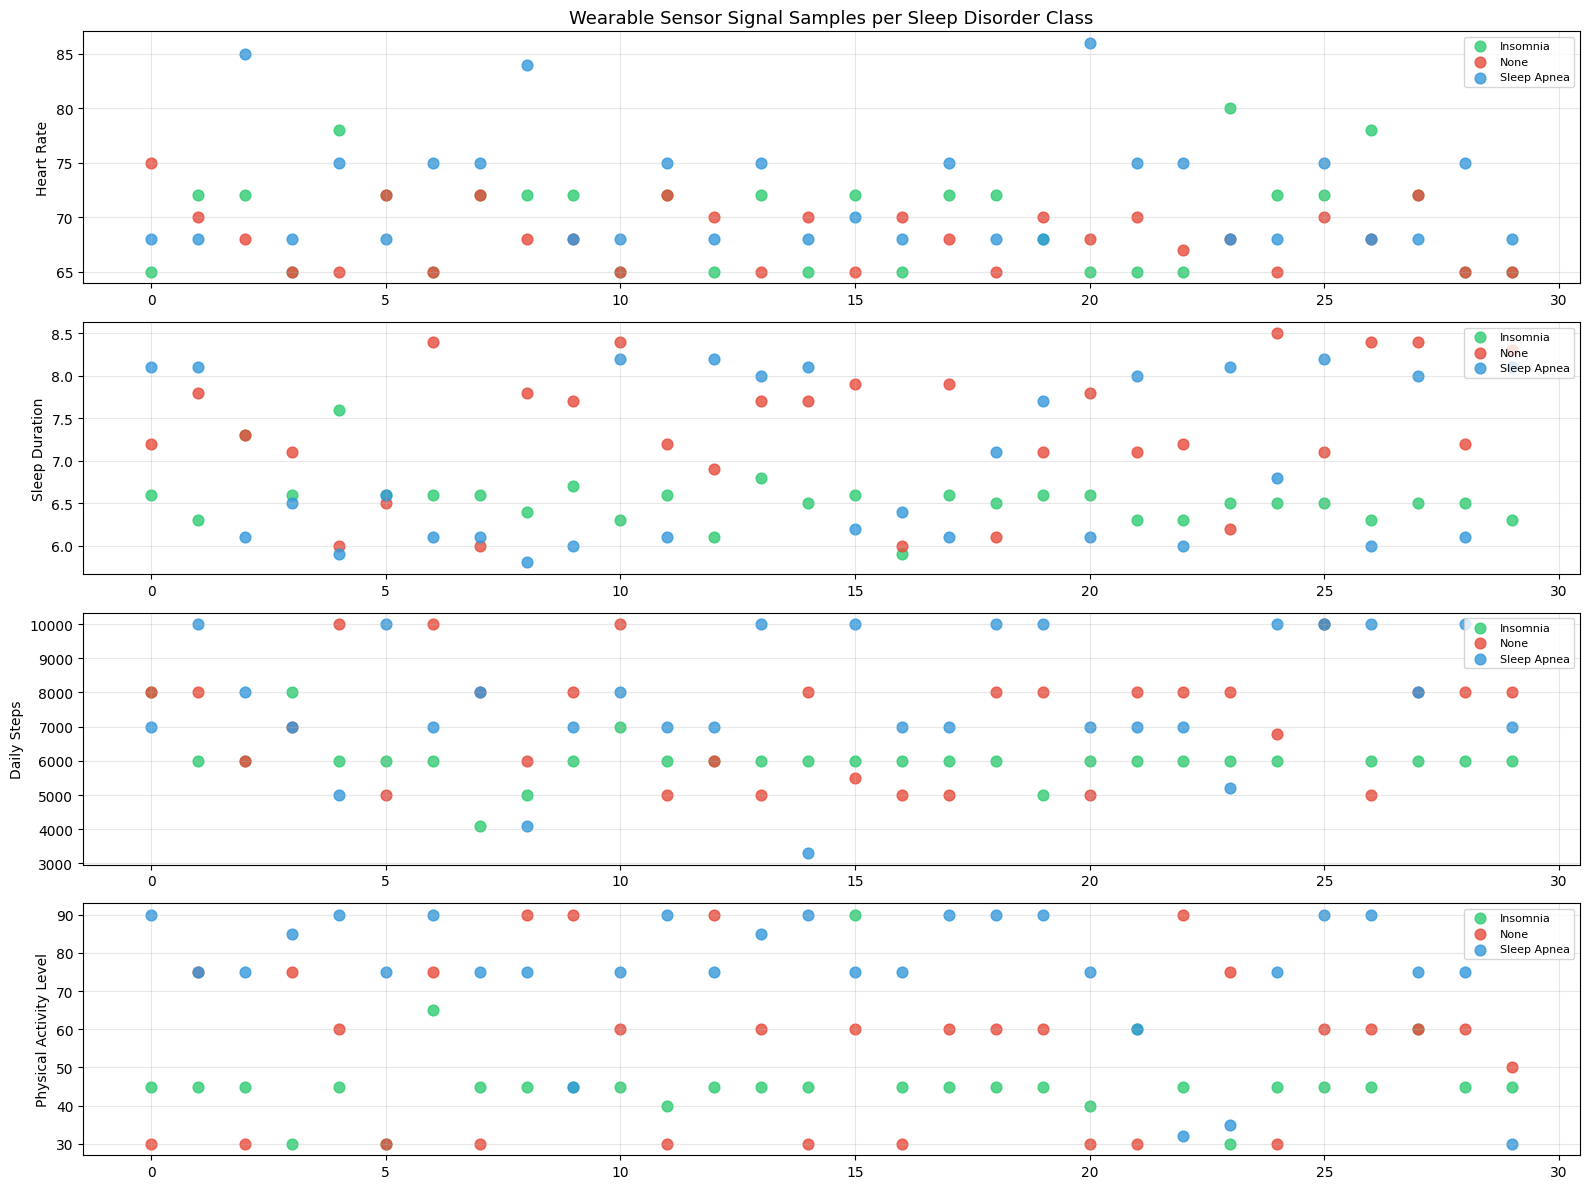

In [ ]:

def visualize_sensor_samples(n_samples=30):
    sensor_cols = [c for c in ['Heart Rate', 'Blood Oxygen Level',
                                'Sleep Duration', 'Daily Steps',
                                'Physical Activity Level', 'Stress Level']
                   if c in df.columns][:4]

    # Safe sort — key=str prevents NaN TypeError
    df_vis       = df.dropna(subset=['Sleep Disorder']).copy()
    disorder_list = sorted(df_vis['Sleep Disorder'].unique(), key=str)
    colors_vis    = ['#2ecc71', '#e74c3c', '#3498db']

    fig, axes = plt.subplots(len(sensor_cols), 1, figsize=(16, 12), sharex=False)
    if len(sensor_cols) == 1:
        axes = [axes]

    for ax, feat in zip(axes, sensor_cols):
        for disorder, color in zip(disorder_list, colors_vis):
            subset  = df_vis[df_vis['Sleep Disorder'] == disorder][feat].values
            n_pick  = min(n_samples, len(subset))
            indices = np.random.choice(len(subset), size=n_pick, replace=False)
            ax.scatter(range(n_pick), subset[indices],
                       label=disorder, color=color, s=60, alpha=0.8)
        ax.set_ylabel(feat, fontsize=10)
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)

    axes[0].set_title('Wearable Sensor Signal Samples per Sleep Disorder Class',
                      fontsize=13)
    plt.tight_layout(); plt.show()

visualize_sensor_samples(n_samples=30)


# Data Preprocessing



In [ ]:

df_proc = df.dropna(subset=['Sleep Disorder']).copy() 
df_proc = df_proc.reset_index(drop=True)

# Encode categorical columns
le_gender = LabelEncoder()
df_proc['Gender_enc'] = le_gender.fit_transform(df_proc['Gender'])

le_bmi = LabelEncoder()
df_proc['BMI_enc'] = le_bmi.fit_transform(df_proc['BMI Category'])


if 'Blood Pressure' in df_proc.columns:
    try:
        bp_split = df_proc['Blood Pressure'].str.split('/', expand=True).astype(float)
        df_proc['BP_Systolic']  = bp_split[0]
        df_proc['BP_Diastolic'] = bp_split[1]
        df_proc['Pulse_Pressure'] = df_proc['BP_Systolic'] - df_proc['BP_Diastolic']
    except Exception:
        df_proc['BP_Systolic']    = 120.0
        df_proc['BP_Diastolic']   = 80.0
        df_proc['Pulse_Pressure'] = 40.0


if 'Sleep Duration' in df_proc.columns:
    df_proc['Sleep_Efficiency_Proxy'] = (df_proc['Sleep Duration'] /
                                          df_proc['Sleep Duration'].max())


if 'Physical Activity Level' in df_proc.columns and 'Stress Level' in df_proc.columns:
    df_proc['Activity_Stress_Ratio'] = (df_proc['Physical Activity Level'] /
                                          (df_proc['Stress Level'] + 1e-6))


if 'Daily Steps' in df_proc.columns and 'Physical Activity Level' in df_proc.columns:
    df_proc['Steps_per_Activity'] = (df_proc['Daily Steps'] /
                                      (df_proc['Physical Activity Level'] + 1e-6))

print(f"Records after dropping NaN Sleep Disorder rows: {len(df_proc)}")
print(f"Features after engineering: {df_proc.shape[1]}")
df_proc.head(3)


Records after dropping NaN Sleep Disorder rows: 374
Features after engineering: 21


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,...,Daily Steps,Sleep Disorder,Gender_enc,BMI_enc,BP_Systolic,BP_Diastolic,Pulse_Pressure,Sleep_Efficiency_Proxy,Activity_Stress_Ratio,Steps_per_Activity
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,...,4200,None,1,3,126.0,83.0,43.0,0.717647,6.999999,99.999998
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,...,10000,None,1,0,125.0,80.0,45.0,0.729412,7.499999,166.666664
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,...,10000,None,1,0,125.0,80.0,45.0,0.729412,7.499999,166.666664


In [ ]:

FEATURE_COLS = [c for c in df_proc.select_dtypes(include=[np.number]).columns
                if c not in ['Person ID'] and 'Age Group' not in c]
print(f"Total numeric features for modelling: {len(FEATURE_COLS)}")
print(FEATURE_COLS)


Total numeric features for modelling: 15
['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'Heart Rate', 'Daily Steps', 'Gender_enc', 'BMI_enc', 'BP_Systolic', 'BP_Diastolic', 'Pulse_Pressure', 'Sleep_Efficiency_Proxy', 'Activity_Stress_Ratio', 'Steps_per_Activity']


In [ ]:

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from tensorflow.keras.utils import to_categorical


le_target = LabelEncoder()
df_proc['label'] = le_target.fit_transform(df_proc['Sleep Disorder'])
CLASS_NAMES = list(le_target.classes_)
N_CLASSES   = len(CLASS_NAMES)
print("Encoded classes:", {i: c for i, c in enumerate(CLASS_NAMES)})

X = df_proc[FEATURE_COLS].values.astype(np.float32)
y = df_proc['label'].values

# 70 / 15 / 15 stratified split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y)
X_train_2d, X_val, y_train_raw, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)


scaler = StandardScaler()
X_train_2d = scaler.fit_transform(X_train_2d)
X_val       = scaler.transform(X_val)
X_test      = scaler.transform(X_test)


smote = SMOTE(random_state=42)
X_train_2d, y_train_raw = smote.fit_resample(X_train_2d, y_train_raw)


TIMESTEPS = 1
X_train = X_train_2d.reshape(-1, TIMESTEPS, X_train_2d.shape[1])
X_val   = X_val.reshape(-1, TIMESTEPS, X_val.shape[1])
X_test  = X_test.reshape(-1, TIMESTEPS, X_test.shape[1])


y_train = to_categorical(y_train_raw, num_classes=N_CLASSES)
y_val   = to_categorical(y_val,       num_classes=N_CLASSES)
y_test  = to_categorical(y_test,      num_classes=N_CLASSES)

print(f"\nX_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}    y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}   y_test : {y_test.shape}")
print(f"Sequence shape fed to LSTM: {X_train.shape[1:]}")


Encoded classes: {0: 'Insomnia', 1: 'None', 2: 'Sleep Apnea'}

X_train: (459, 1, 15)  y_train: (459, 3)
X_val  : (56, 1, 15)    y_val  : (56, 3)
X_test : (57, 1, 15)   y_test : (57, 3)
Sequence shape fed to LSTM: (1, 15)


## Normalisation Verification


In [ ]:

for name, arr in [('X_train (3D)', X_train), ('X_val (3D)', X_val), ('X_test (3D)', X_test)]:
    flat = arr.reshape(-1, arr.shape[-1])
    print(f"{name}: mean≈{flat.mean():.4f}  std≈{flat.std():.4f}  "
          f"min={flat.min():.3f}  max={flat.max():.3f}  "
          f"shape={arr.shape}")


X_train (3D): mean≈0.0663  std≈1.0162  min=-2.972  max=4.576  shape=(459, 1, 15)
X_val (3D): mean≈0.0722  std≈1.0094  min=-2.216  max=4.576  shape=(56, 1, 15)
X_test (3D): mean≈0.0073  std≈1.0362  min=-2.972  max=4.576  shape=(57, 1, 15)


## Class Balance After SMOTE (Bar Chart per Split)


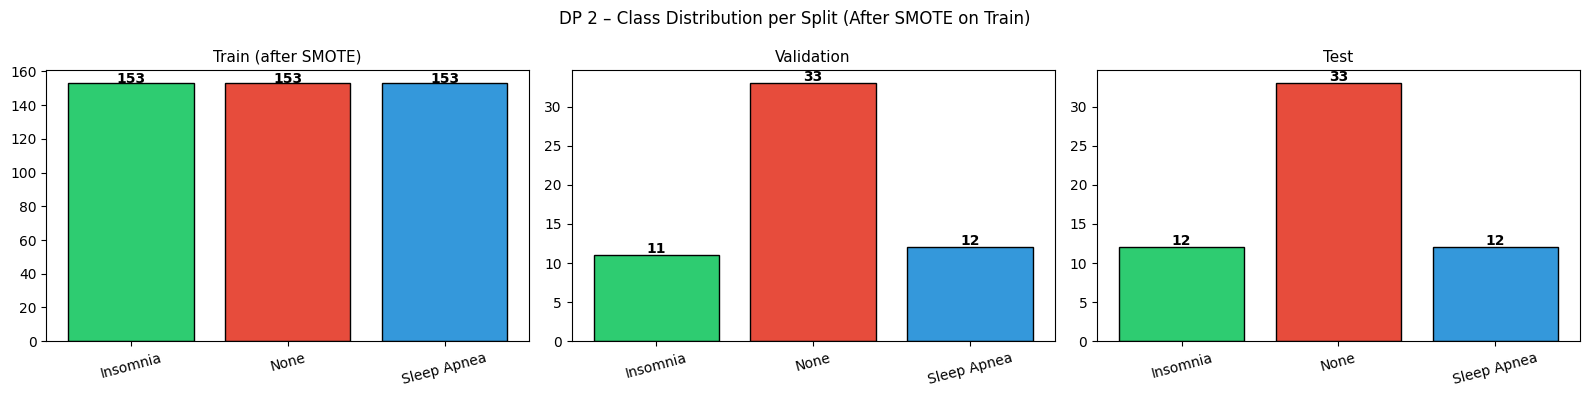

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors_dp2 = ['#2ecc71', '#e74c3c', '#3498db']
for ax, (name, y_arr) in zip(axes, [
        ('Train (after SMOTE)', y_train),
        ('Validation', y_val),
        ('Test', y_test)]):
    y_idx = np.argmax(y_arr, axis=1)
    unique, counts = np.unique(y_idx, return_counts=True)
    ax.bar([CLASS_NAMES[u] for u in unique], counts,
           color=[colors_dp2[u] for u in unique], edgecolor='black')
    ax.set_title(f'{name}', fontsize=11)
    ax.tick_params(axis='x', rotation=15)
    for i, (u, c) in enumerate(zip(unique, counts)):
        ax.text(i, c + 0.3, str(c), ha='center', fontsize=10, fontweight='bold')
plt.suptitle('DP 2 – Class Distribution per Split (After SMOTE on Train)', fontsize=12)
plt.tight_layout(); plt.show()


##  Feature Correlation Matrix



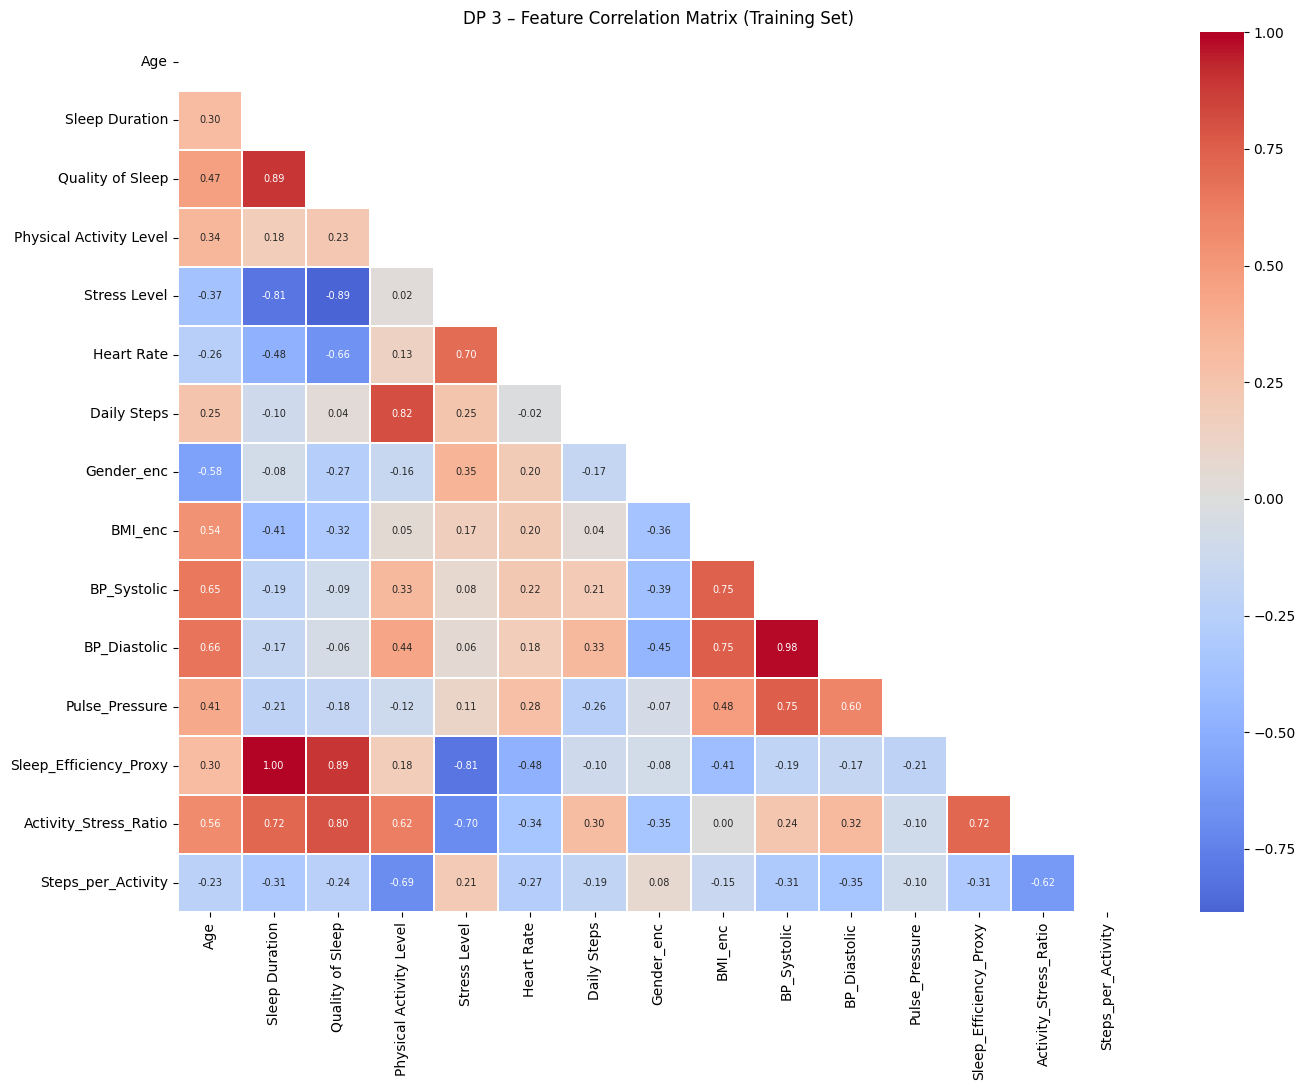

High-correlation pairs (|r|>0.9): [('Sleep Duration', 'Sleep_Efficiency_Proxy'), ('BP_Systolic', 'BP_Diastolic')]


In [ ]:

corr_df = pd.DataFrame(X_train.reshape(-1, X_train.shape[-1]),
                        columns=FEATURE_COLS).corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.3,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('DP 3 – Feature Correlation Matrix (Training Set)', fontsize=12)
plt.tight_layout(); plt.show()

high_corr = [(corr_df.columns[i], corr_df.columns[j])
             for i in range(len(corr_df))
             for j in range(i+1, len(corr_df))
             if abs(corr_df.iloc[i,j]) > 0.9]
print(f"High-correlation pairs (|r|>0.9): "
      f"{high_corr if high_corr else 'None found ✓'}")


## LSTM Input Shape & Sequence Verification



In [ ]:

print("LSTM Input Tensor Shapes:")
for name, arr in [('X_train', X_train), ('X_val', X_val), ('X_test', X_test)]:
    print(f"  {name}: {arr.shape}  "
          f"→ ({arr.shape[0]} samples, {arr.shape[1]} timesteps, "
          f"{arr.shape[2]} features)")

print("\nOne-Hot Label Verification:")
for name, y_arr in [('y_train', y_train), ('y_val', y_val), ('y_test', y_test)]:
    row_sums  = y_arr.sum(axis=1)
    is_binary = np.all((y_arr == 0) | (y_arr == 1))
    is_sumone = np.allclose(row_sums, 1)
    print(f"  {name}: shape={y_arr.shape}  "
          f"one-hot_valid={is_binary and is_sumone}  "
          f"n_classes={y_arr.shape[1]}")


LSTM Input Tensor Shapes:
  X_train: (459, 1, 15)  → (459 samples, 1 timesteps, 15 features)
  X_val: (56, 1, 15)  → (56 samples, 1 timesteps, 15 features)
  X_test: (57, 1, 15)  → (57 samples, 1 timesteps, 15 features)

One-Hot Label Verification:
  y_train: shape=(459, 3)  one-hot_valid=True  n_classes=3
  y_val: shape=(56, 3)  one-hot_valid=True  n_classes=3
  y_test: shape=(57, 3)  one-hot_valid=True  n_classes=3


## Train / Val / Test Shape & Memory Report


In [ ]:

for name, X_arr, y_arr in [('Train', X_train, y_train),
                             ('Val',   X_val,   y_val),
                             ('Test',  X_test,  y_test)]:
    mb_x = X_arr.nbytes / (1024**2)
    mb_y = y_arr.nbytes / (1024**2)
    print(f"{name:6s}: X={X_arr.shape}  y={y_arr.shape}  "
          f"dtype={X_arr.dtype}  X_mem≈{mb_x:.3f} MB  y_mem≈{mb_y:.3f} MB")
print(f"\nTotal input features per timestep : {X_train.shape[2]}")
print(f"LSTM sequence length (timesteps)  : {X_train.shape[1]}")


Train : X=(459, 1, 15)  y=(459, 3)  dtype=float32  X_mem≈0.026 MB  y_mem≈0.011 MB
Val   : X=(56, 1, 15)  y=(56, 3)  dtype=float32  X_mem≈0.003 MB  y_mem≈0.001 MB
Test  : X=(57, 1, 15)  y=(57, 3)  dtype=float32  X_mem≈0.003 MB  y_mem≈0.001 MB

Total input features per timestep : 15
LSTM sequence length (timesteps)  : 1


# Defining Model Architecture
<hr>

## **Stacked LSTM (Base Model)**




In [ ]:

def lstm_model():
    model = Sequential(name='Stacked_LSTM')

    
    model.add(LSTM(128, return_sequences=True,
                   input_shape=(TIMESTEPS, X_train.shape[2]),
                   name='lstm_1'))
    model.add(BatchNormalization(name='bn_1'))
    model.add(Dropout(0.3, name='drop_1'))

    
    model.add(LSTM(64, return_sequences=False, name='lstm_2'))
    model.add(BatchNormalization(name='bn_2'))
    model.add(Dropout(0.3, name='drop_2'))

    
    model.add(Dense(64, activation='relu', name='dense_1'))
    model.add(Dropout(0.2, name='drop_3'))
    model.add(Dense(N_CLASSES, activation='softmax', name='output'))

    return model

model = lstm_model()
model.compile(optimizer=Adam(1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


Model: "Stacked_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 1, 128)         │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 1, 128)         │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,259 (501.01 KB)

 Trainable params: 127,875 (499.51 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:

checkpointer = [
    EarlyStopping(monitor='val_accuracy', verbose=1,
                  restore_best_weights=True, mode='max', patience=15),
    ModelCheckpoint('best_model.h5', monitor='val_accuracy', verbose=1,
                    save_best_only=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                      min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=80,
    callbacks=checkpointer,
    validation_data=(X_val, y_val)
)


Epoch 1/80
11/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4745 - loss: 1.1083 
Epoch 1: val_accuracy improved from None to 0.19643, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 70ms/step - accuracy: 0.6492 - loss: 0.8325 - val_accuracy: 0.1964 - val_loss: 1.0836 - learning_rate: 0.0010
Epoch 2/80
11/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8199 - loss: 0.5999 
Epoch 2: val_accuracy improved from 0.19643 to 0.23214, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8366 - loss: 0.5230 - val_accuracy: 0.2321 - val_loss: 1.0812 - learning_rate: 0.0010
Epoch 3/80
11/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9064 - loss: 0.3788 
Epoch 3: val_accuracy did not improve from 0.23214
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8715 - loss: 0.4731 - val_accuracy: 0.1964 - val_loss: 1.0672 - learning_rate: 0.0010
Epoch 4/80
12/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8437 - loss: 0.5379 
Epoch 4: val_accuracy did not improve from 0.23214
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8606 - loss: 0.4934 - val_accuracy: 0.1964 - val_loss: 1.0587 - learning_rate: 0.0010
Epoch 5/80
11/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8922 - loss: 0.3232 
Epoch 5: val_accuracy improved from 0.23214 to 0.30357, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8584 - loss: 0.4580 - val_accuracy: 0.3036 - val_loss: 1.0453 - learning_rate: 0.0010
Epoch 6/80
11/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8532 - loss: 0.5212 
Epoch 6: val_accuracy did not improve from 0.30357
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8540 - loss: 0.4931 - val_accuracy: 0.3036 - val_loss: 1.0285 - learning_rate: 0.0010
Epoch 7/80
11/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8545 - loss: 0.5334 
Epoch 7: val_accuracy improved from 0.30357 to 0.32143, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8671 - loss: 0.4535 - val_accuracy: 0.3214 - val_loss: 1.0134 - learning_rate: 0.0010
Epoch 8/80
11/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8955 - loss: 0.3793 
Epoch 8: val_accuracy improved from 0.32143 to 0.48214, saving model to best_model.h5


...


Epoch 10: finished saving model to best_model.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8649 - loss: 0.4351 - val_accuracy: 0.7857 - val_loss: 0.9427 - learning_rate: 0.0010
Epoch 11/80
12/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8713 - loss: 0.4029 
Epoch 11: val_accuracy did not improve from 0.78571
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8802 - loss: 0.4366 - val_accuracy: 0.7321 - val_loss: 0.9339 - learning_rate: 0.0010
Epoch 12/80
11/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8938 - loss: 0.3524 
Epoch 12: val_accuracy improved from 0.78571 to 0.83929, saving model to best_model.h5



Epoch 12: finished saving model to best_model.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8889 - loss: 0.3710 - val_accuracy: 0.8393 - val_loss: 0.8860 - learning_rate: 0.0010
Epoch 13/80
11/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9044 - loss: 0.3763 
Epoch 13: val_accuracy did not improve from 0.83929
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8845 - loss: 0.4102 - val_accuracy: 0.8214 - val_loss: 0.8721 - learning_rate: 0.0010
Epoch 14/80
12/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8336 - loss: 0.4912 
Epoch 14: val_accuracy did not improve from 0.83929
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8649 - loss: 0.4399 - val_accuracy: 0.8214 - val_loss: 0.8527 - learning_rate: 0.0010
Epoch 15/80
11/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8887 - loss: 0.3490 
Epoch 15: val_accuracy improved from 0.83929 to 0.85714, saving model to best_model.h5



Epoch 15: finished saving model to best_model.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8911 - loss: 0.3646 - val_accuracy: 0.8571 - val_loss: 0.8072 - learning_rate: 0.0010
Epoch 16/80
 9/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8772 - loss: 0.4027 
Epoch 16: val_accuracy improved from 0.85714 to 0.94643, saving model to best_model.h5



Epoch 16: finished saving model to best_model.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8845 - loss: 0.3867 - val_accuracy: 0.9464 - val_loss: 0.7592 - learning_rate: 0.0010
Epoch 17/80
11/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8376 - loss: 0.5450 
Epoch 17: val_accuracy did not improve from 0.94643
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8758 - loss: 0.4131 - val_accuracy: 0.9107 - val_loss: 0.7173 - learning_rate: 0.0010
Epoch 18/80
11/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8720 - loss: 0.3965 
Epoch 18: val_accuracy did not improve from 0.94643
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8780 - loss: 0.4091 - val_accuracy: 0.8750 - val_loss: 0.6907 - learning_rate: 0.0010
Epoch 19/80
12/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8888 - loss: 0.3618 
Epoch 19: val_accuracy improved from 0.94643 to 0.96429, saving model to best_model.h5



Epoch 19: finished saving model to best_model.h5
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8824 - loss: 0.3700 - val_accuracy: 0.9643 - val_loss: 0.6528 - learning_rate: 0.0010
Epoch 20/80
12/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8705 - loss: 0.3998  
Epoch 20: val_accuracy did not improve from 0.96429
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8824 - loss: 0.4018 - val_accuracy: 0.9643 - val_loss: 0.5990 - learning_rate: 0.0010
Epoch 21/80
10/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8890 - loss: 0.3411 
Epoch 21: val_accuracy did not improve from 0.96429
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8867 - loss: 0.3772 - val_accuracy: 0.9643 - val_loss: 0.5642 - learning_rate: 0.0010
Epoch 22/80
12/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8782 - loss: 0.4368 
Epoch 22: val_accuracy did not improve from 0.96429
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8911 - loss: 0.4021 - val_accuracy: 0.9643 - val_loss: 0.5301 

# Model Evaluation
<hr>

Let's see the output results:
* Loss & Accuracy plot
* Sample predictions (predicted vs actual label)
* Confusion Matrix
* Classification Report


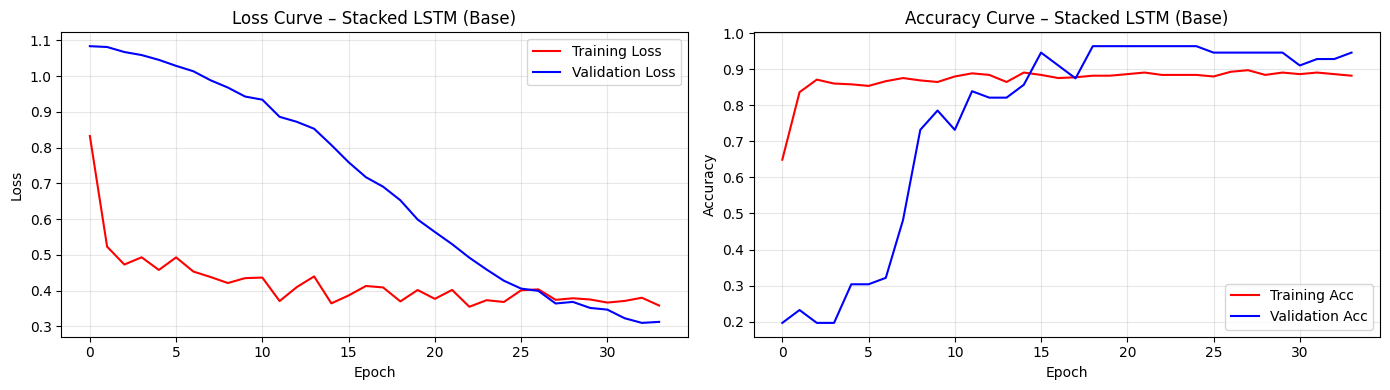

In [ ]:

def loss_plot(hist, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(hist.history['loss'],     'r', linewidth=1.5, label='Training Loss')
    axes[0].plot(hist.history['val_loss'], 'b', linewidth=1.5, label='Validation Loss')
    axes[0].set_title(f'Loss Curve {title}', fontsize=12)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(hist.history['accuracy'],     'r', linewidth=1.5, label='Training Acc')
    axes[1].plot(hist.history['val_accuracy'], 'b', linewidth=1.5, label='Validation Acc')
    axes[1].set_title(f'Accuracy Curve {title}', fontsize=12)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout(); plt.show()

loss_plot(history, '– Stacked LSTM (Base)')


In [ ]:

preds  = model.predict(X_test)
y_pred = np.argmax(preds, axis=1)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 315ms/step


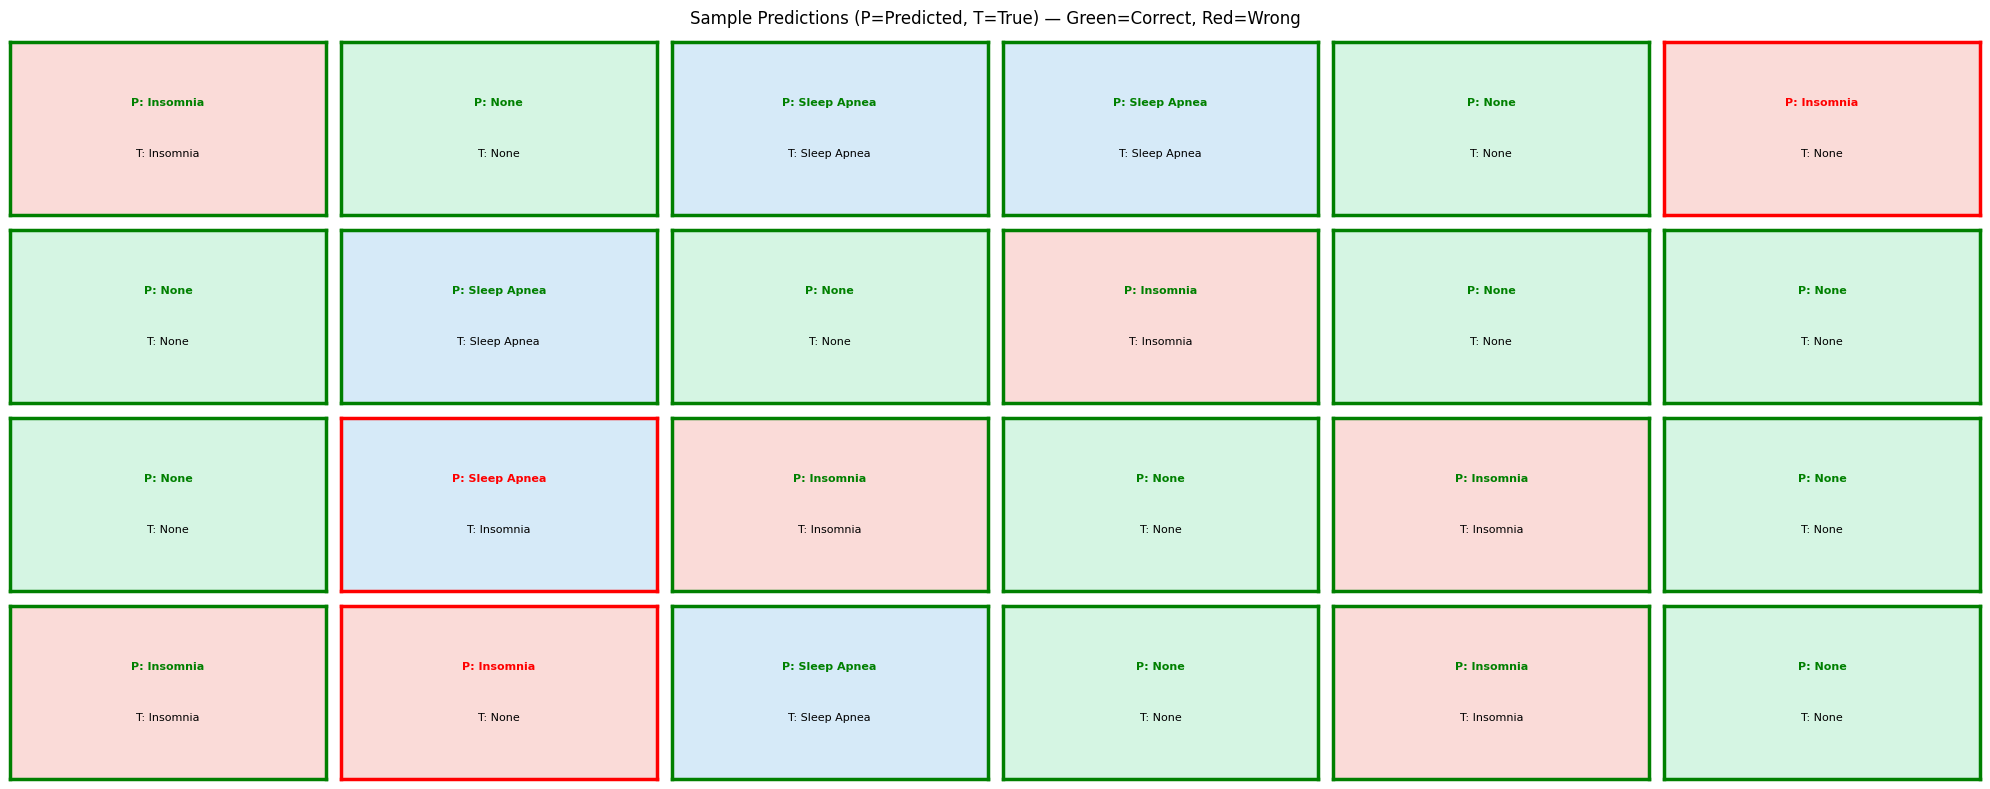

In [ ]:

def check_predictions(X_t, y_pred_arr, y_true_oh, label_names, n=24):
    """Display a grid of predicted vs actual sleep disorder labels."""
    y_true_idx = np.argmax(y_true_oh, axis=1)
    indices    = np.random.choice(len(y_pred_arr), size=n, replace=False)
    colors_bg  = {'None':'#d5f5e3', 'Insomnia':'#fadbd8', 'Sleep Apnea':'#d6eaf8'}

    figure = plt.figure(figsize=(20, 8))
    for i, idx in enumerate(indices):
        ax = figure.add_subplot(4, 6, i+1, xticks=[], yticks=[])
        pred_name = label_names[y_pred_arr[idx]]
        true_name = label_names[y_true_idx[idx]]
        correct   = pred_name == true_name
        bg = colors_bg.get(pred_name, '#ffffff')
        ax.set_facecolor(bg)
        ax.text(0.5, 0.65, f'P: {pred_name}',  ha='center', va='center',
                fontsize=8, fontweight='bold',
                color='green' if correct else 'red',
                transform=ax.transAxes)
        ax.text(0.5, 0.35, f'T: {true_name}', ha='center', va='center',
                fontsize=8, transform=ax.transAxes)
        for spine in ax.spines.values():
            spine.set_edgecolor('green' if correct else 'red')
            spine.set_linewidth(2.5)
    plt.suptitle('Sample Predictions (P=Predicted, T=True) — Green=Correct, Red=Wrong',
                 fontsize=12)
    plt.tight_layout(); plt.show()

check_predictions(X_test, y_pred, y_test, CLASS_NAMES)


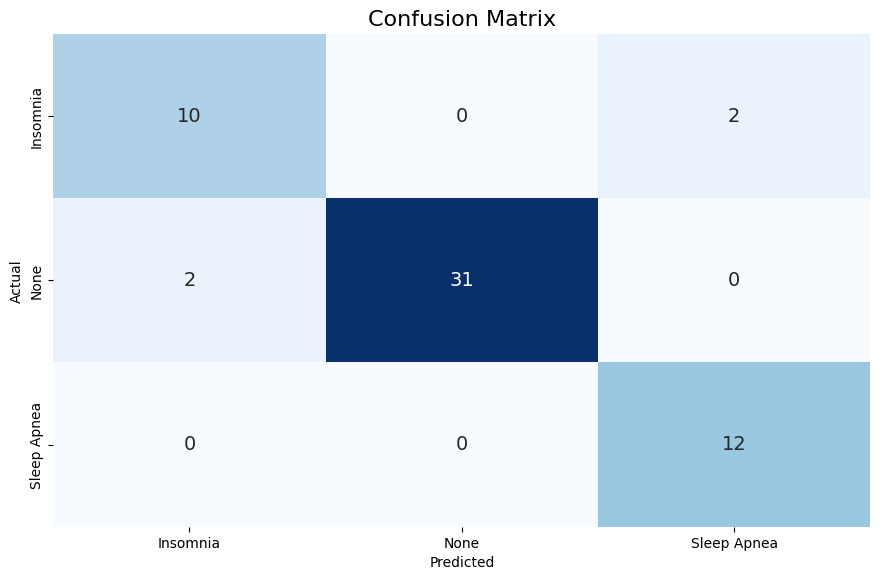

In [ ]:

def conf_mat(y_true_oh, y_pred_arr, labels):
    CLASS_LABELS = labels
    cm_data = confusion_matrix(np.argmax(y_true_oh, axis=1), y_pred_arr)
    cm = pd.DataFrame(cm_data, columns=CLASS_LABELS, index=CLASS_LABELS)
    cm.index.name   = 'Actual'
    cm.columns.name = 'Predicted'
    plt.figure(figsize=(9, 6))
    plt.title('Confusion Matrix', fontsize=16)
    sns.set(font_scale=1.1)
    sns.heatmap(cm, cbar=False, cmap='Blues', annot=True,
                annot_kws={'size': 14}, fmt='g')
    plt.tight_layout(); plt.show()

conf_mat(y_test, y_pred, CLASS_NAMES)


In [ ]:

print(classification_report(np.argmax(y_test, axis=1), y_pred,
                             target_names=CLASS_NAMES, digits=3))


              precision    recall  f1-score   support

    Insomnia      0.833     0.833     0.833        12
        None      1.000     0.939     0.969        33
 Sleep Apnea      0.857     1.000     0.923        12

    accuracy                          0.930        57
   macro avg      0.897     0.924     0.908        57
weighted avg      0.935     0.930     0.931        57



In [ ]:

for name, X_e, y_e in [('Training',   X_train, y_train),
                        ('Validation', X_val,   y_val),
                        ('Test',       X_test,  y_test)]:
    loss_val, acc_val = model.evaluate(X_e, y_e, verbose=0)
    print(f"On {name:12s} Data  →  Loss: {loss_val:.4f}  |  Accuracy: {acc_val*100:.2f}%")


On Training     Data  →  Loss: 0.6284  |  Accuracy: 90.20%
On Validation   Data  →  Loss: 0.6528  |  Accuracy: 96.43%
On Test         Data  →  Loss: 0.6242  |  Accuracy: 92.98%


##  **Bidirectional LSTM**

In [ ]:

def bilstm_model():
    model = Sequential(name='BiLSTM')

    model.add(Bidirectional(LSTM(128, return_sequences=True),
                             input_shape=(TIMESTEPS, X_train.shape[2]),
                             name='bilstm_1'))
    model.add(BatchNormalization()); model.add(Dropout(0.3))

    model.add(Bidirectional(LSTM(64, return_sequences=False), name='bilstm_2'))
    model.add(BatchNormalization()); model.add(Dropout(0.3))

    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(N_CLASSES, activation='softmax'))

    return model

bilstm = bilstm_model()
bilstm.compile(optimizer=Adam(1e-3),
               loss='categorical_crossentropy',
               metrics=['accuracy'])
bilstm.summary()


Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bilstm_1 (Bidirectional)        │ (None, 1, 256)         │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321,795 (1.23 MB)

 Trainable params: 321,027 (1.22 MB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:

cb_bilstm = [
    EarlyStopping(monitor='val_accuracy', patience=15,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_bilstm.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                      min_lr=1e-6, verbose=0)
]
history_bilstm = bilstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80, batch_size=32,
    callbacks=cb_bilstm, verbose=1
)


Epoch 1/80
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6629 - loss: 0.8255

15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - accuracy: 0.7516 - loss: 0.7242 - val_accuracy: 0.3929 - val_loss: 1.0864 - learning_rate: 0.0010
Epoch 2/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8649 - loss: 0.5243 - val_accuracy: 0.3929 - val_loss: 1.0882 - learning_rate: 0.0010
Epoch 3/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8388 - loss: 0.4906 - val_accuracy: 0.3929 - val_loss: 1.0701 - learning_rate: 0.0010
Epoch 4/80
12/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8791 - loss: 0.4415 

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8736 - loss: 0.4647 - val_accuracy: 0.5357 - val_loss: 1.0480 - learning_rate: 0.0010
Epoch 5/80
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9043 - loss: 0.3616

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8911 - loss: 0.4041 - val_accuracy: 0.5536 - val_loss: 1.0413 - learning_rate: 0.0010
Epoch 6/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8780 - loss: 0.3962 - val_accuracy: 0.5536 - val_loss: 1.0208 - learning_rate: 0.0010
Epoch 7/80
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8888 - loss: 0.4046 

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8824 - loss: 0.4166 - val_accuracy: 0.6429 - val_loss: 0.9908 - learning_rate: 0.0010
Epoch 8/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8802 - loss: 0.4222 - val_accuracy: 0.5714 - val_loss: 0.9793 - learning_rate: 0.0010
Epoch 9/80
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8692 - loss: 0.4631 

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8649 - loss: 0.4540 - val_accuracy: 0.7500 - val_loss: 0.9516 - learning_rate: 0.0010
Epoch 10/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8671 - loss: 0.4076 - val_accuracy: 0.6786 - val_loss: 0.9343 - learning_rate: 0.0010
Epoch 11/80
12/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8499 - loss: 0.4605

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8758 - loss: 0.4201 - val_accuracy: 0.9821 - val_loss: 0.8934 - learning_rate: 0.0010
Epoch 12/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8671 - loss: 0.4003 - val_accuracy: 0.9643 - val_loss: 0.8625 - learning_rate: 0.0010
Epoch 13/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8824 - loss: 0.3842 - val_accuracy: 0.9821 - val_loss: 0.8245 - learning_rate: 0.0010
Epoch 14/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8802 - loss: 0.3993 - val_accuracy: 0.9821 - val_loss: 0.7996 - learning_rate: 0.0010
Epoch 15/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8889 - loss: 0.4017 - val_accuracy: 0.9643 - val_loss: 0.7646 - learning_rate: 0.0010
Epoch 16/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8627 - loss: 0.3826 - val_accuracy: 0.9821 - val_loss: 0.7306 - learning_rate: 0.0010
Epoch 17/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8932 - loss: 0.3784 - val_accuracy

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 590ms/step
=== Bidirectional LSTM – Classification Report ===
              precision    recall  f1-score   support

    Insomnia      0.846     0.917     0.880        12
        None      1.000     0.939     0.969        33
 Sleep Apnea      0.923     1.000     0.960        12

    accuracy                          0.947        57
   macro avg      0.923     0.952     0.936        57
weighted avg      0.951     0.947     0.948        57



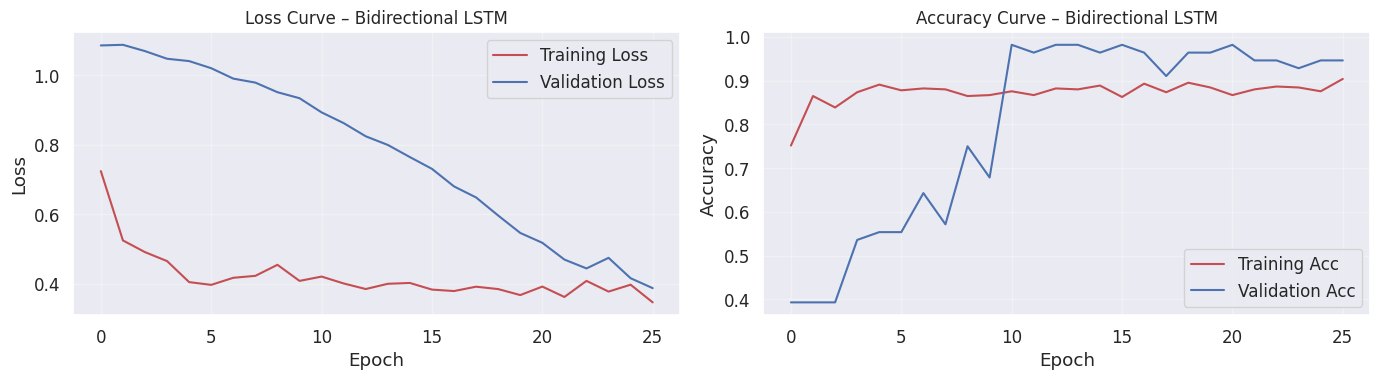

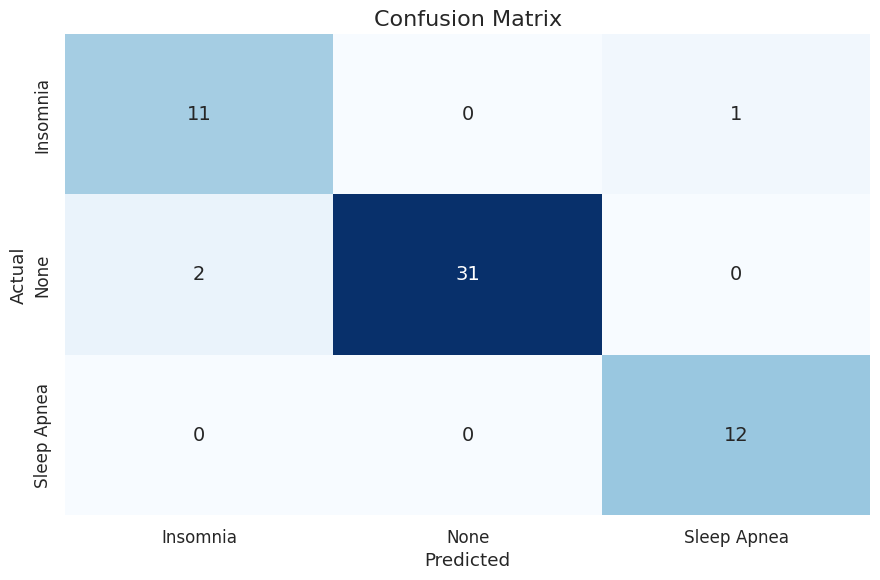

In [ ]:

preds_bilstm  = bilstm.predict(X_test)
y_pred_bilstm = np.argmax(preds_bilstm, axis=1)
print("=== Bidirectional LSTM – Classification Report ===")
print(classification_report(np.argmax(y_test, axis=1), y_pred_bilstm,
                             target_names=CLASS_NAMES, digits=3))
loss_plot(history_bilstm, '– Bidirectional LSTM')
conf_mat(y_test, y_pred_bilstm, CLASS_NAMES)


## **CNN-LSTM Hybrid**

In [ ]:

def cnnlstm_model():
    inp = Input(shape=(TIMESTEPS, X_train.shape[2]), name='input')

    
    x = Conv1D(64, kernel_size=1, padding='same', activation='relu', name='conv1')(inp)
    x = BatchNormalization(name='bn_conv1')(x)
    x = Dropout(0.2)(x)

    x = Conv1D(128, kernel_size=1, padding='same', activation='relu', name='conv2')(x)
    x = BatchNormalization(name='bn_conv2')(x)
    x = Dropout(0.2)(x)

    
    x = LSTM(64, return_sequences=False, name='lstm_cnn')(x)
    x = BatchNormalization()(x); x = Dropout(0.3)(x)

    # Classifier
    x = Dense(64, activation='relu')(x); x = Dropout(0.2)(x)
    out = Dense(N_CLASSES, activation='softmax', name='output')(x)

    return Model(inp, out, name='CNN_LSTM')

cnnlstm = cnnlstm_model()
cnnlstm.compile(optimizer=Adam(1e-3),
                loss='categorical_crossentropy',
                metrics=['accuracy'])
cnnlstm.summary()


Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 1, 15)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 1, 64)          │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv1 (BatchNormalization)   │ (None, 1, 64)          │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 1, 128)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv2 (BatchNormalization)   │ (None, 1, 128)         │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_cnn (LSTM)                 │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64,131 (250.51 KB)

 Trainable params: 63,619 (248.51 KB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:

cb_cnnlstm = [
    EarlyStopping(monitor='val_accuracy', patience=15,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_cnnlstm.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                      min_lr=1e-6, verbose=0)
]
history_cnnlstm = cnnlstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80, batch_size=32,
    callbacks=cb_cnnlstm, verbose=1
)


Epoch 1/80
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4823 - loss: 1.2285

15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.6405 - loss: 0.9082 - val_accuracy: 0.5357 - val_loss: 1.0142 - learning_rate: 0.0010
Epoch 2/80
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8200 - loss: 0.4831 

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8475 - loss: 0.4633 - val_accuracy: 0.6964 - val_loss: 0.9696 - learning_rate: 0.0010
Epoch 3/80
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8686 - loss: 0.4459 

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8606 - loss: 0.4673 - val_accuracy: 0.8036 - val_loss: 0.9399 - learning_rate: 0.0010
Epoch 4/80
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8315 - loss: 0.5711 

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8540 - loss: 0.4497 - val_accuracy: 0.8214 - val_loss: 0.9176 - learning_rate: 0.0010
Epoch 5/80
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8524 - loss: 0.4581 

...

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8693 - loss: 0.4531 - val_accuracy: 0.8750 - val_loss: 0.8333 - learning_rate: 0.0010
Epoch 7/80
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8709 - loss: 0.4891  

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8715 - loss: 0.4405 - val_accuracy: 0.8929 - val_loss: 0.8105 - learning_rate: 0.0010
Epoch 8/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8519 - loss: 0.4520 - val_accuracy: 0.8929 - val_loss: 0.7697 - learning_rate: 0.0010
Epoch 9/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8671 - loss: 0.4205 - val_accuracy: 0.8929 - val_loss: 0.7174 - learning_rate: 0.0010
Epoch 10/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8627 - loss: 0.4164 - val_accuracy: 0.8929 - val_loss: 0.6620 - learning_rate: 0.0010
Epoch 11/80
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8990 - loss: 0.3498 

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8736 - loss: 0.4107 - val_accuracy: 0.9107 - val_loss: 0.6234 - learning_rate: 0.0010
Epoch 12/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8715 - loss: 0.3817 - val_accuracy: 0.9107 - val_loss: 0.6067 - learning_rate: 0.0010
Epoch 13/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8649 - loss: 0.4451 - val_accuracy: 0.9107 - val_loss: 0.5515 - learning_rate: 0.0010
Epoch 14/80
 9/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8609 - loss: 0.4704 

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8758 - loss: 0.4345 - val_accuracy: 0.9464 - val_loss: 0.4913 - learning_rate: 0.0010
Epoch 15/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8780 - loss: 0.4096 - val_accuracy: 0.9464 - val_loss: 0.4749 - learning_rate: 0.0010
Epoch 16/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8867 - loss: 0.3497 - val_accuracy: 0.9107 - val_loss: 0.4553 - learning_rate: 0.0010
Epoch 17/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8715 - loss: 0.4043 - val_accuracy: 0.9286 - val_loss: 0.4352 - learning_rate: 0.0010
Epoch 18/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8845 - loss: 0.4025 - val_accuracy: 0.9286 - val_loss: 0.4045 - learning_rate: 0.0010
Epoch 19/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8758 - loss: 0.3800 - val_accuracy: 0.9286 - val_loss: 0.4079 - learning_rate: 0.0010
Epoch 20/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8780 - loss: 0.3967 - val_accuracy

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8889 - loss: 0.3782 - val_accuracy: 0.9821 - val_loss: 0.2780 - learning_rate: 0.0010
Epoch 26/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8824 - loss: 0.3845 - val_accuracy: 0.9821 - val_loss: 0.2617 - learning_rate: 0.0010
Epoch 27/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9041 - loss: 0.3624 - val_accuracy: 0.9464 - val_loss: 0.2515 - learning_rate: 0.0010
Epoch 28/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9041 - loss: 0.3384 - val_accuracy: 0.9821 - val_loss: 0.2811 - learning_rate: 0.0010
Epoch 29/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8911 - loss: 0.3747 - val_accuracy: 0.9464 - val_loss: 0.2645 - learning_rate: 0.0010
Epoch 30/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8889 - loss: 0.3846 - val_accuracy: 0.9464 - val_loss: 0.2570 - learning_rate: 0.0010
Epoch 31/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8911 - loss: 0.3427 - val_accuracy: 0.92

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
=== CNN-LSTM Hybrid – Classification Report ===
              precision    recall  f1-score   support

    Insomnia      1.000     0.833     0.909        12
        None      1.000     1.000     1.000        33
 Sleep Apnea      0.857     1.000     0.923        12

    accuracy                          0.965        57
   macro avg      0.952     0.944     0.944        57
weighted avg      0.970     0.965     0.965        57



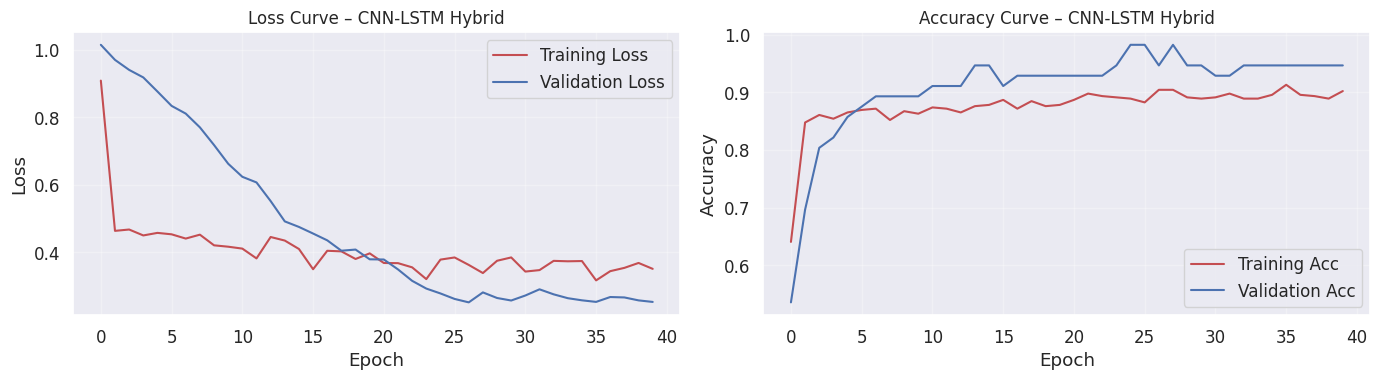

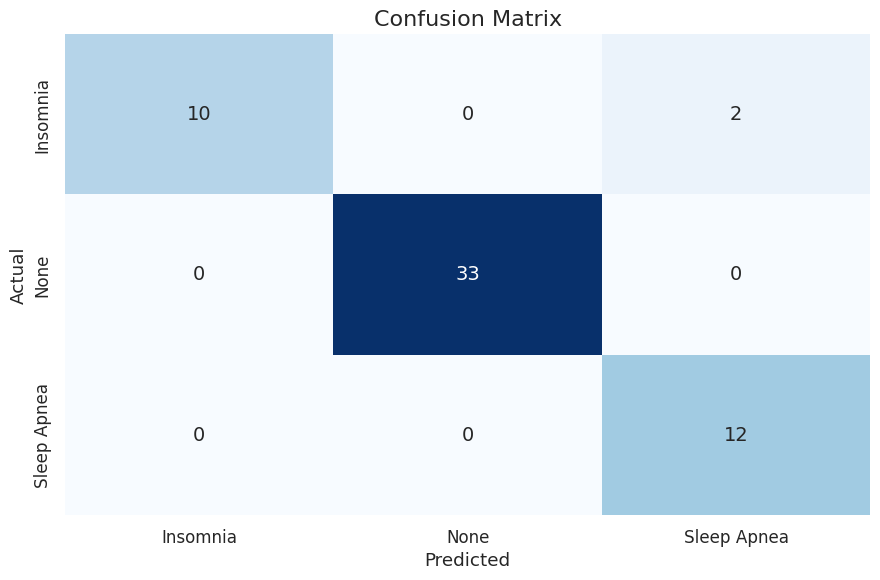

In [ ]:

preds_cnnlstm  = cnnlstm.predict(X_test)
y_pred_cnnlstm = np.argmax(preds_cnnlstm, axis=1)
print("=== CNN-LSTM Hybrid – Classification Report ===")
print(classification_report(np.argmax(y_test, axis=1), y_pred_cnnlstm,
                             target_names=CLASS_NAMES, digits=3))
loss_plot(history_cnnlstm, '– CNN-LSTM Hybrid')
conf_mat(y_test, y_pred_cnnlstm, CLASS_NAMES)


## **Transformer with Multi-Head Self-Attention**

In [ ]:

def transformer_model():
    inp = Input(shape=(TIMESTEPS, X_train.shape[2]), name='input')

    
    attn_out = MultiHeadAttention(
        num_heads=4, key_dim=X_train.shape[2], name='mha'
    )(inp, inp)
    attn_out = Dropout(0.1)(attn_out)
    x = LayerNormalization(epsilon=1e-6)(inp + attn_out)   # residual + norm

    # Feed-Forward block
    ff = Dense(128, activation='relu')(x)
    ff = Dropout(0.1)(ff)
    ff = Dense(X_train.shape[2])(ff)
    x  = LayerNormalization(epsilon=1e-6)(x + ff)           # residual + norm

    
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x); x = Dropout(0.3)(x)
    out = Dense(N_CLASSES, activation='softmax', name='output')(x)

    return Model(inp, out, name='Transformer')

transformer = transformer_model()
transformer.compile(optimizer=Adam(1e-3),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])
transformer.summary()


Model: "Transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 1, 15)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha                 │ (None, 1, 15)     │      3,795 │ input[0][0],      │
│ (MultiHeadAttentio… │                   │            │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 1, 15)     │          0 │ mha[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 15)     │          0 │ input[0][0],      │
│                     │                   │            │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1, 15)     │         30 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1, 128)    │      2,048 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 1, 128)    │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1, 15)     │      1,935 │ dropout_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1, 15)     │          0 │ layer_normalizat… │
│                     │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 15)     │         30 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 15)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      1,024 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 64)        │          0 │ dense_5[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 3)         │        195 │ dropout_10[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 9,057 (35.38 KB)

 Trainable params: 9,057 (35.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

cb_transformer = [
    EarlyStopping(monitor='val_accuracy', patience=15,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_transformer.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5,
                      min_lr=1e-6, verbose=0)
]
history_transformer = transformer.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=80, batch_size=32,
    callbacks=cb_transformer, verbose=1
)


Epoch 1/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4707 - loss: 1.0308

15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.5948 - loss: 0.8933 - val_accuracy: 0.9107 - val_loss: 0.5728 - learning_rate: 0.0010
Epoch 2/80
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7913 - loss: 0.6507 

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8083 - loss: 0.6243 - val_accuracy: 0.9286 - val_loss: 0.4120 - learning_rate: 0.0010
Epoch 3/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8431 - loss: 0.5174 - val_accuracy: 0.9107 - val_loss: 0.3606 - learning_rate: 0.0010
Epoch 4/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8627 - loss: 0.4931 - val_accuracy: 0.9107 - val_loss: 0.3681 - learning_rate: 0.0010
Epoch 5/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8715 - loss: 0.4628 - val_accuracy: 0.9107 - val_loss: 0.3663 - learning_rate: 0.0010
Epoch 6/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8693 - loss: 0.4476 - val_accuracy: 0.9286 - val_loss: 0.3594 - learning_rate: 0.0010
Epoch 7/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8780 - loss: 0.4395 - val_accuracy: 0.9286 - val_loss: 0.3775 - learning_rate: 0.0010
Epoch 8/80
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8867 - loss: 0.4020 - val_accuracy: 0.9286 - v

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
=== Transformer – Classification Report ===
              precision    recall  f1-score   support

    Insomnia      0.833     0.833     0.833        12
        None      1.000     0.909     0.952        33
 Sleep Apnea      0.733     0.917     0.815        12

    accuracy                          0.895        57
   macro avg      0.856     0.886     0.867        57
weighted avg      0.909     0.895     0.898        57



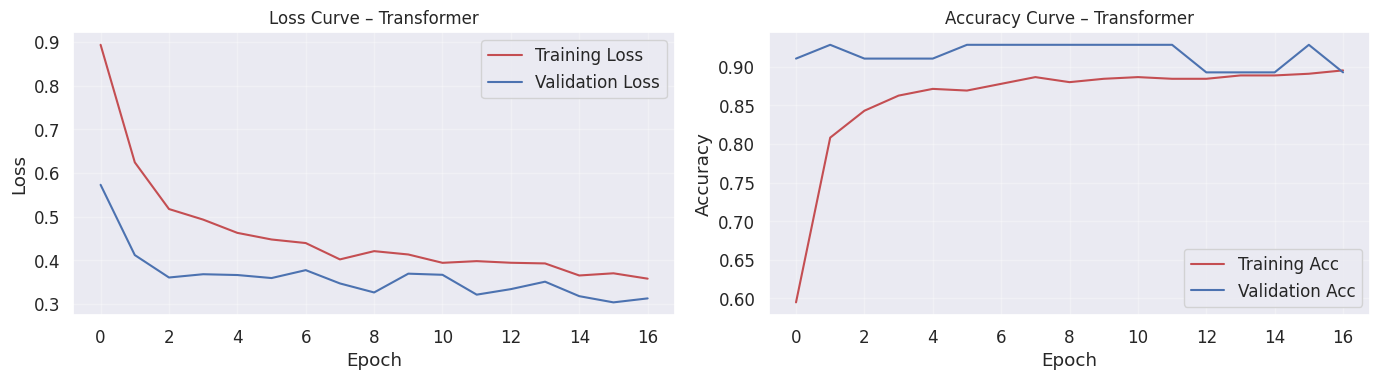

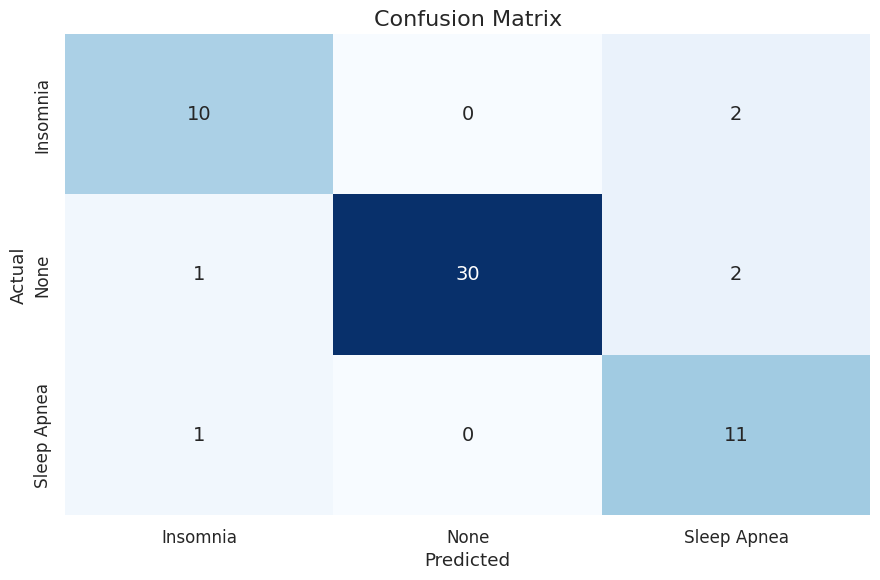

In [ ]:

preds_transformer  = transformer.predict(X_test)
y_pred_transformer = np.argmax(preds_transformer, axis=1)
print("=== Transformer – Classification Report ===")
print(classification_report(np.argmax(y_test, axis=1), y_pred_transformer,
                             target_names=CLASS_NAMES, digits=3))
loss_plot(history_transformer, '– Transformer')
conf_mat(y_test, y_pred_transformer, CLASS_NAMES)


## **Model Comparison**


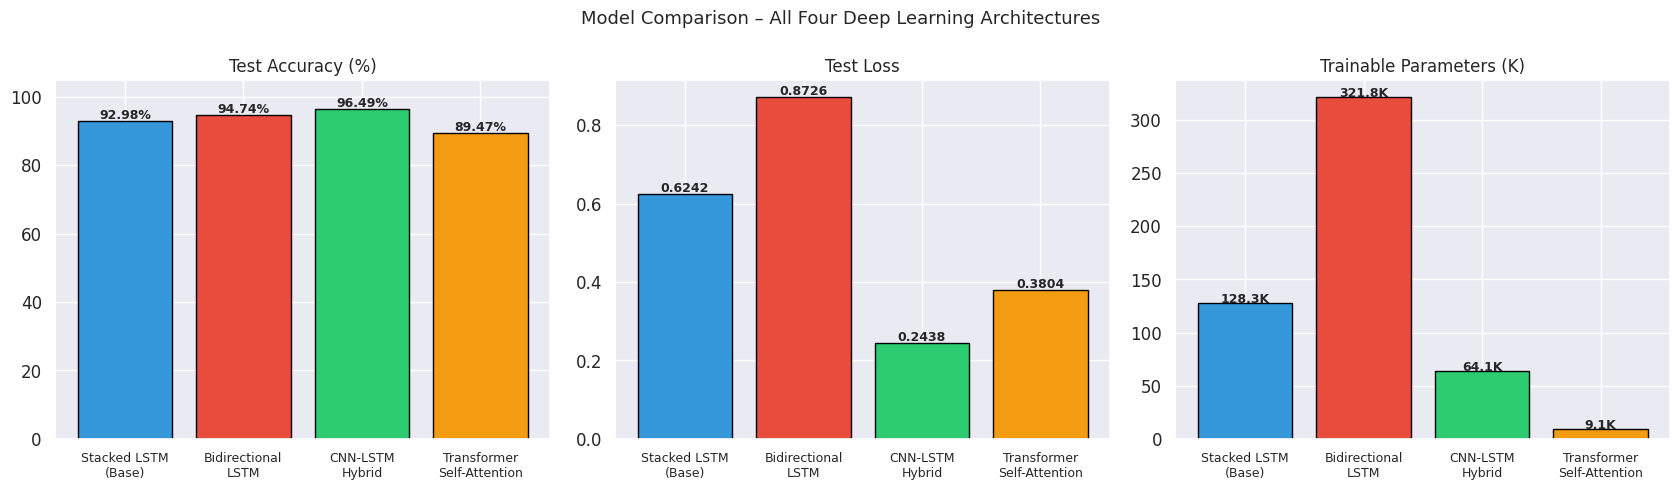


Model                          Test Acc   Test Loss       Params
---------------------------------------------------------------
Stacked LSTM (Base)              92.98%      0.6242      128,259
Bidirectional LSTM               94.74%      0.8726      321,795
CNN-LSTM Hybrid                  96.49%      0.2438       64,131
Transformer Self-Attention       89.47%      0.3804        9,057


In [ ]:

model_names = ['Stacked LSTM\n(Base)', 'Bidirectional\nLSTM',
               'CNN-LSTM\nHybrid', 'Transformer\nSelf-Attention']

def eval_model(m):
    loss_val, acc = m.evaluate(X_test, y_test, verbose=0)
    return acc, loss_val

acc_base,  loss_base  = eval_model(model)
acc_bi,    loss_bi    = eval_model(bilstm)
acc_cnn,   loss_cnn   = eval_model(cnnlstm)
acc_trans, loss_trans = eval_model(transformer)

accs   = [acc_base,  acc_bi,   acc_cnn,   acc_trans]
losses = [loss_base, loss_bi,  loss_cnn,  loss_trans]
params = [model.count_params(), bilstm.count_params(),
          cnnlstm.count_params(), transformer.count_params()]

colors_cmp = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
x = np.arange(len(model_names))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Accuracy
axes[0].bar(x, [a*100 for a in accs], color=colors_cmp, edgecolor='black')
axes[0].set_xticks(x); axes[0].set_xticklabels(model_names, fontsize=9)
axes[0].set_title('Test Accuracy (%)', fontsize=12); axes[0].set_ylim(0, 105)
for xi, a in zip(x, accs):
    axes[0].text(xi, a*100+0.5, f'{a*100:.2f}%', ha='center', fontsize=9, fontweight='bold')

# Loss
axes[1].bar(x, losses, color=colors_cmp, edgecolor='black')
axes[1].set_xticks(x); axes[1].set_xticklabels(model_names, fontsize=9)
axes[1].set_title('Test Loss', fontsize=12)
for xi, l in zip(x, losses):
    axes[1].text(xi, l+0.005, f'{l:.4f}', ha='center', fontsize=9, fontweight='bold')

# Parameters
axes[2].bar(x, [p/1e3 for p in params], color=colors_cmp, edgecolor='black')
axes[2].set_xticks(x); axes[2].set_xticklabels(model_names, fontsize=9)
axes[2].set_title('Trainable Parameters (K)', fontsize=12)
for xi, p in zip(x, params):
    axes[2].text(xi, p/1e3+0.1, f'{p/1e3:.1f}K', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Model Comparison – All Four Deep Learning Architectures', fontsize=13)
plt.tight_layout(); plt.show()

print("\n{:<28} {:>10} {:>11} {:>12}".format('Model','Test Acc','Test Loss','Params'))
print("-"*63)
for n, a, l, p in zip(model_names, accs, losses, params):
    print(f"{n.replace(chr(10),' '):<28} {a*100:>9.2f}% {l:>11.4f} {p:>12,}")


## **Fine Tuning**



## 1. Changing epoch, learning rate and batch size

In [ ]:

best_idx_ft  = int(np.argmax(accs))
model_fns_ft = [lstm_model, bilstm_model, cnnlstm_model, transformer_model]
model_names_ft = ['Stacked LSTM','BiLSTM','CNN-LSTM','Transformer']
print(f"Fine-tuning: {model_names_ft[best_idx_ft]}")

ft_model_1 = model_fns_ft[best_idx_ft]()
ft_model_1.compile(optimizer=Adam(learning_rate=5e-4),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

cb_ft1 = [
    EarlyStopping(monitor='val_accuracy', patience=20,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_ft1.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7,
                      min_lr=1e-7, verbose=0)
]

history_ft1 = ft_model_1.fit(
    X_train, y_train,
    batch_size=16,
    epochs=100,
    callbacks=cb_ft1,
    validation_data=(X_val, y_val)
)


Fine-tuning: CNN-LSTM
Epoch 1/100
15/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3567 - loss: 1.5545 

29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.5033 - loss: 1.1542 - val_accuracy: 0.8393 - val_loss: 1.0516 - learning_rate: 5.0000e-04
Epoch 2/100
15/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7733 - loss: 0.6539 

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7756 - loss: 0.6145 - val_accuracy: 0.8750 - val_loss: 0.9860 - learning_rate: 5.0000e-04
Epoch 3/100
15/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8007 - loss: 0.5826 

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8017 - loss: 0.5796 - val_accuracy: 0.9107 - val_loss: 0.9144 - learning_rate: 5.0000e-04
Epoch 4/100
14/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7770 - loss: 0.5982 

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8214 - loss: 0.5355 - val_accuracy: 0.9286 - val_loss: 0.8369 - learning_rate: 5.0000e-04
Epoch 5/100
25/29 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8107 - loss: 0.5428

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8235 - loss: 0.5207 - val_accuracy: 0.9464 - val_loss: 0.7441 - learning_rate: 5.0000e-04
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8453 - loss: 0.5009 - val_accuracy: 0.9464 - val_loss: 0.6632 - learning_rate: 5.0000e-04
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8606 - loss: 0.4494 - val_accuracy: 0.9286 - val_loss: 0.5786 - learning_rate: 5.0000e-04
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8453 - loss: 0.4889 - val_accuracy: 0.9286 - val_loss: 0.4904 - learning_rate: 5.0000e-04
Epoch 9/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8540 - loss: 0.4994 - val_accuracy: 0.9286 - val_loss: 0.4408 - learning_rate: 5.0000e-04
Epoch 10/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8736 - loss: 0.4133 - val_accuracy: 0.9286 - val_loss: 0.4120 - learning_rate: 5.0000e-04
Epoch 11/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8366 - loss: 0.

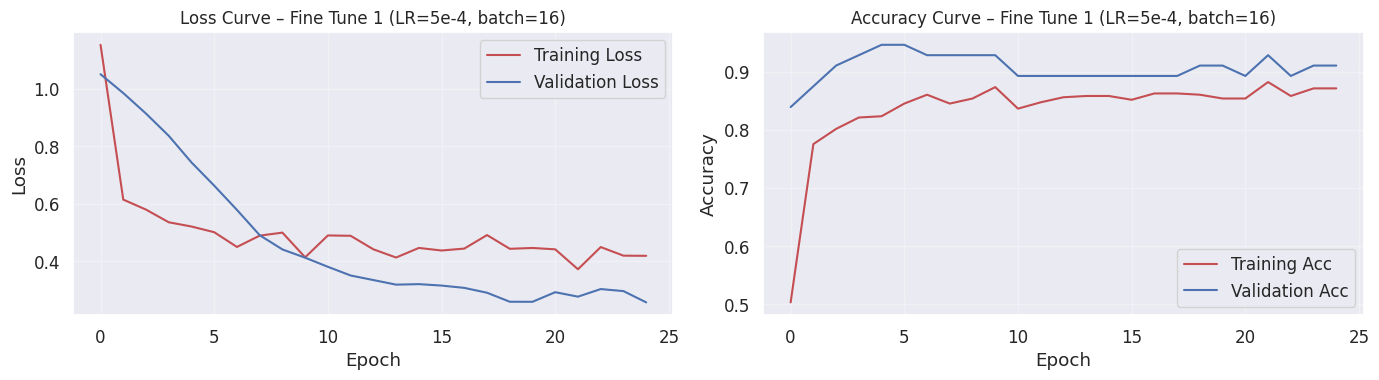

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
              precision    recall  f1-score   support

    Insomnia      0.909     0.833     0.870        12
        None      1.000     0.939     0.969        33
 Sleep Apnea      0.800     1.000     0.889        12

    accuracy                          0.930        57
   macro avg      0.903     0.924     0.909        57
weighted avg      0.939     0.930     0.931        57



In [ ]:
loss_plot(history_ft1, f'– Fine Tune 1 (LR=5e-4, batch=16)')
preds_ft1  = ft_model_1.predict(X_test)
y_pred_ft1 = np.argmax(preds_ft1, axis=1)
print(classification_report(np.argmax(y_test, axis=1), y_pred_ft1,
                             target_names=CLASS_NAMES, digits=3))


## 2. Changing optimizer (SGD with Momentum)

In [ ]:

ft_model_2 = model_fns_ft[best_idx_ft]()

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1e-2,
    decay_steps=100 * (len(X_train) // 32)
)
ft_model_2.compile(optimizer=SGD(learning_rate=lr_schedule, momentum=0.9,
                                   nesterov=True),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

cb_ft2 = [
    EarlyStopping(monitor='val_accuracy', patience=20,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_ft2.h5', monitor='val_accuracy',
                    save_best_only=True, verbose=0)
]

history_ft2 = ft_model_2.fit(
    X_train, y_train,
    batch_size=32,
    epochs=100,
    callbacks=cb_ft2,
    validation_data=(X_val, y_val)
)

Epoch 1/100
 9/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4309 - loss: 1.2154

15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - accuracy: 0.6688 - loss: 0.8125 - val_accuracy: 0.5714 - val_loss: 0.9843
Epoch 2/100
10/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8291 - loss: 0.6090

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8214 - loss: 0.5756 - val_accuracy: 0.8571 - val_loss: 0.9301
Epoch 3/100
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8457 - loss: 0.5045

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8366 - loss: 0.5317 - val_accuracy: 0.8750 - val_loss: 0.8863
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8711 - loss: 0.4379

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8758 - loss: 0.4477 - val_accuracy: 0.8929 - val_loss: 0.8426
Epoch 5/100
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8562 - loss: 0.4612

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8627 - loss: 0.4642 - val_accuracy: 0.9286 - val_loss: 0.8094
Epoch 6/100
13/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8805 - loss: 0.3811

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8627 - loss: 0.4299 - val_accuracy: 0.9464 - val_loss: 0.7681
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8736 - loss: 0.4418 - val_accuracy: 0.9464 - val_loss: 0.7110
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8736 - loss: 0.4328 - val_accuracy: 0.9464 - val_loss: 0.6804
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8715 - loss: 0.4425 - val_accuracy: 0.9107 - val_loss: 0.6500
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8824 - loss: 0.4308 - val_accuracy: 0.9107 - val_loss: 0.6168
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8802 - loss: 0.4017 - val_accuracy: 0.8929 - val_loss: 0.5920
Epoch 12/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8758 - loss: 0.3837 - val_accuracy: 0.8929 - val_loss: 0.5586
Epoch 13/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8845 - loss: 0.4224 - val_accuracy: 0.9107 - v

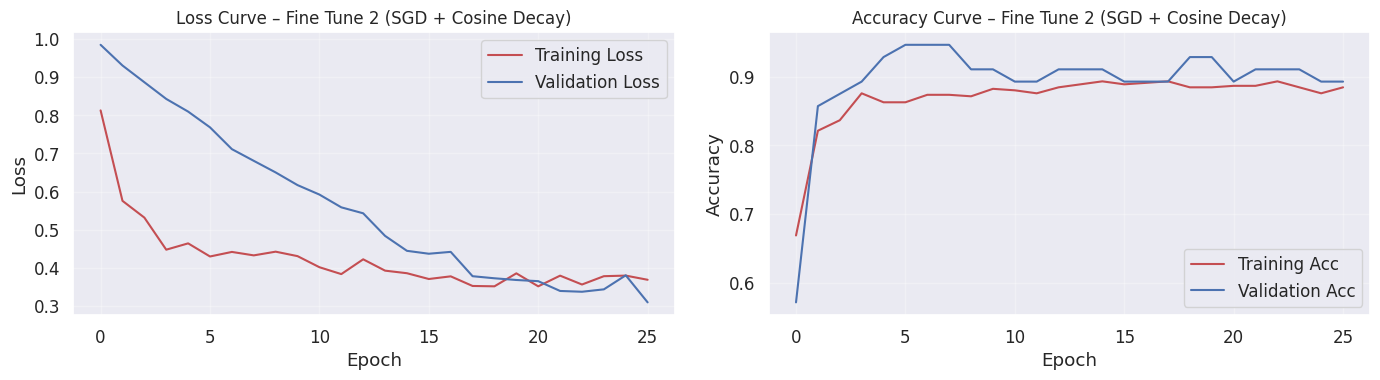

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step
              precision    recall  f1-score   support

    Insomnia      0.917     0.917     0.917        12
        None      1.000     0.939     0.969        33
 Sleep Apnea      0.857     1.000     0.923        12

    accuracy                          0.947        57
   macro avg      0.925     0.952     0.936        57
weighted avg      0.952     0.947     0.948        57



In [ ]:
loss_plot(history_ft2, '– Fine Tune 2 (SGD + Cosine Decay)')
preds_ft2  = ft_model_2.predict(X_test)
y_pred_ft2 = np.argmax(preds_ft2, axis=1)
print(classification_report(np.argmax(y_test, axis=1), y_pred_ft2,
                             target_names=CLASS_NAMES, digits=3))


## Fine Tuning Comparison – Base vs FT1 vs FT2

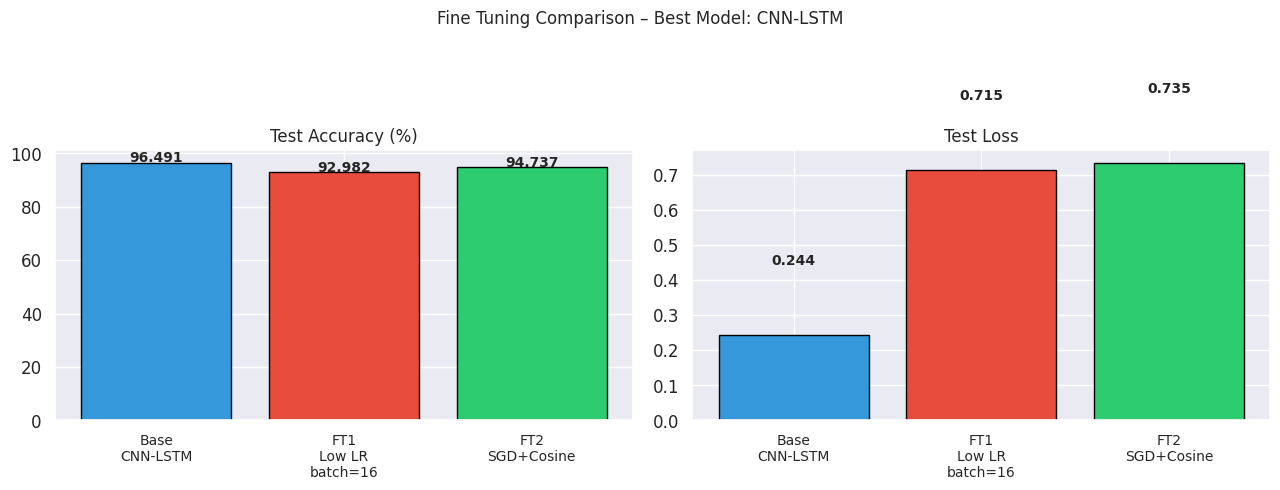


Strategy                       Accuracy       Loss
--------------------------------------------------
Base CNN-LSTM                    96.49%     0.2438
FT1 Low LR batch=16              92.98%     0.7151
FT2 SGD+Cosine                   94.74%     0.7347


In [ ]:

def get_metrics(m):
    l, a = m.evaluate(X_test, y_test, verbose=0)
    return a, l

acc_ft_base, loss_ft_base = get_metrics([model, bilstm, cnnlstm, transformer][best_idx_ft])
acc_ft1_val, loss_ft1_val = get_metrics(ft_model_1)
acc_ft2_val, loss_ft2_val = get_metrics(ft_model_2)

ft_names_cmp  = [f'Base\n{model_names_ft[best_idx_ft]}',
                 'FT1\nLow LR\nbatch=16',
                 'FT2\nSGD+Cosine']
ft_accs_cmp   = [acc_ft_base, acc_ft1_val, acc_ft2_val]
ft_losses_cmp = [loss_ft_base, loss_ft1_val, loss_ft2_val]
colors_ft     = ['#3498db', '#e74c3c', '#2ecc71']
x = np.arange(3)

fig, axes_ft = plt.subplots(1, 2, figsize=(13, 5))
for ax, vals, title in zip(
        axes_ft,
        [[a*100 for a in ft_accs_cmp], ft_losses_cmp],
        ['Test Accuracy (%)', 'Test Loss']):
    bars = ax.bar(x, vals, color=colors_ft, edgecolor='black')
    ax.set_xticks(x); ax.set_xticklabels(ft_names_cmp, fontsize=10)
    ax.set_title(title, fontsize=12)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle(f'Fine Tuning Comparison – Best Model: {model_names_ft[best_idx_ft]}',
             fontsize=12)
plt.tight_layout(); plt.show()

print("\n{:<28} {:>10} {:>10}".format('Strategy','Accuracy','Loss'))
print("-"*50)
for n, a, l in zip(ft_names_cmp, ft_accs_cmp, ft_losses_cmp):
    print(f"{n.replace(chr(10),' '):<28} {a*100:>9.2f}% {l:>10.4f}")


# Model Saving

In [ ]:

import json, joblib


best_ft_val   = [acc_ft_base, acc_ft1_val, acc_ft2_val]
best_ft_idx   = int(np.argmax(best_ft_val))
best_ft_model = [[model, bilstm, cnnlstm, transformer][best_idx_ft],
                  ft_model_1, ft_model_2][best_ft_idx]
ft_strategy   = ['Base','FT1-LowLR','FT2-SGD'][best_ft_idx]


model_json = best_ft_model.to_json()
with open("sleep_model.json", "w") as json_file:
    json_file.write(model_json)

# Save weights
best_ft_model.save_weights("sleep_model_weights.h5")

# Save full model
best_ft_model.save("sleep_model_full.h5")


joblib.dump(scaler,    'sleep_scaler.pkl')
joblib.dump(le_target, 'sleep_label_encoder.pkl')

with open('sleep_features.txt', 'w') as f:
    for feat in FEATURE_COLS:
        f.write(feat + '\n')

print(f"Saved best model (strategy: {ft_strategy}) to disk ✓")
print("  sleep_model.json  |  sleep_model_weights.h5  |  sleep_model_full.h5")
print("  sleep_scaler.pkl  |  sleep_label_encoder.pkl  |  sleep_features.txt")


ValueError: The filename must end in `.weights.h5`. Received: filepath=sleep_model_weights.h5

In [ ]:

import json, joblib

# Pick best fine-tuned model
best_ft_val   = [acc_ft_base, acc_ft1_val, acc_ft2_val]
best_ft_idx   = int(np.argmax(best_ft_val))
best_ft_model = [[model, bilstm, cnnlstm, transformer][best_idx_ft],
                  ft_model_1, ft_model_2][best_ft_idx]
ft_strategy   = ['Base','FT1-LowLR','FT2-SGD'][best_ft_idx]

# Save architecture as JSON
model_json = best_ft_model.to_json()
with open("sleep_model.json", "w") as json_file:
    json_file.write(model_json)

# Save weights
best_ft_model.save_weights("sleep_model.weights.h5")

# Save full model
best_ft_model.save("sleep_model_full.h5")

# Save scaler and label encoder
joblib.dump(scaler,    'sleep_scaler.pkl')
joblib.dump(le_target, 'sleep_label_encoder.pkl')

with open('sleep_features.txt', 'w') as f:
    for feat in FEATURE_COLS:
        f.write(feat + '\n')

print(f"Saved best model (strategy: {ft_strategy}) to disk ✓")
print("  sleep_model.json  |  sleep_model_weights.h5  |  sleep_model_full.h5")
print("  sleep_scaler.pkl  |  sleep_label_encoder.pkl  |  sleep_features.txt")

Saved best model (strategy: Base) to disk ✓
  sleep_model.json  |  sleep_model_weights.h5  |  sleep_model_full.h5
  sleep_scaler.pkl  |  sleep_label_encoder.pkl  |  sleep_features.txt


# Deploying Model for Real-Time Wearable Sensor Prediction



## Loading model architecture and weights

In [ ]:

import json, joblib, numpy as np
from tensorflow.keras.models import model_from_json

model_loaded = model_from_json(open("sleep_model.json", "r").read())
model_loaded.load_weights("sleep_model.weights.h5")

scaler_loaded  = joblib.load('sleep_scaler.pkl')
le_loaded      = joblib.load('sleep_label_encoder.pkl')

with open('sleep_features.txt') as f:
    features_loaded = [line.strip() for line in f.readlines()]

print(f"Model loaded: {model_loaded.name}")
print(f"Classes     : {list(le_loaded.classes_)}")
print(f"Features    : {len(features_loaded)}")

Model loaded: CNN_LSTM
Classes     : ['Insomnia', 'None', 'Sleep Apnea']
Features    : 15


## Real-Time Prediction from Wearable Sensor Readings

In [ ]:
# ── Real-time sleep disorder prediction function ─────────────────────────────
def predict_sleep_disorder(sensor_readings_dict, model, scaler, le, feature_names,
                            timesteps=1):
    """
    Predict sleep disorder from a single wearable sensor observation.

    Parameters
    ----------
    sensor_readings_dict : dict
        Feature name → measured value from wearable device.
        Missing features filled with 0.

    Returns
    -------
    dict: disorder prediction, confidence, class probabilities
    """
    row   = {f: sensor_readings_dict.get(f, 0.0) for f in feature_names}
    X_new = np.array([list(row.values())], dtype=np.float32)
    X_new = scaler.transform(X_new)
    X_new = X_new.reshape(1, timesteps, X_new.shape[1])  # (1, T, F) for LSTM

    proba     = model.predict(X_new, verbose=0)[0]
    pred_enc  = int(np.argmax(proba))
    pred_label= le.inverse_transform([pred_enc])[0]
    confidence= float(proba.max())
    probs     = {le.classes_[i]: round(float(p), 4) for i, p in enumerate(proba)}

    return {
        'prediction':    pred_label,
        'confidence':    round(confidence, 4),
        'probabilities': probs
    }

# ── Example: 3 synthetic wearable sensor profiles ─────────────────────────────
example_readings = [
    # Profile 1: Healthy sleeper – normal HR, high SpO2, low stress
    {'Heart Rate': 68, 'Blood Oxygen Level': 98, 'Sleep Duration': 7.5,
     'Physical Activity Level': 65, 'Stress Level': 4, 'Daily Steps': 8500,
     'Age': 32, 'Gender_enc': 1, 'BMI_enc': 0,
     'BP_Systolic': 118, 'BP_Diastolic': 76, 'Pulse_Pressure': 42,
     'Sleep_Efficiency_Proxy': 0.94, 'Activity_Stress_Ratio': 16.25},

    # Profile 2: Insomnia – low sleep duration, high stress, high HR
    {'Heart Rate': 82, 'Blood Oxygen Level': 97, 'Sleep Duration': 5.2,
     'Physical Activity Level': 30, 'Stress Level': 8, 'Daily Steps': 3200,
     'Age': 45, 'Gender_enc': 0, 'BMI_enc': 2,
     'BP_Systolic': 135, 'BP_Diastolic': 88, 'Pulse_Pressure': 47,
     'Sleep_Efficiency_Proxy': 0.65, 'Activity_Stress_Ratio': 3.75},

    # Profile 3: Sleep Apnea – low SpO2, high BMI, disrupted HR
    {'Heart Rate': 78, 'Blood Oxygen Level': 93, 'Sleep Duration': 6.0,
     'Physical Activity Level': 25, 'Stress Level': 7, 'Daily Steps': 4000,
     'Age': 55, 'Gender_enc': 1, 'BMI_enc': 3,
     'BP_Systolic': 145, 'BP_Diastolic': 92, 'Pulse_Pressure': 53,
     'Sleep_Efficiency_Proxy': 0.75, 'Activity_Stress_Ratio': 3.57},
]

DISORDER_ICONS = {'None': '✅', 'Insomnia': '😴', 'Sleep Apnea': '😮‍💨'}
print("\n=== Real-Time Wearable Sensor Prediction ===\n")
for i, obs in enumerate(example_readings):
    result = predict_sleep_disorder(obs, model_loaded, scaler_loaded,
                                    le_loaded, features_loaded,
                                    timesteps=TIMESTEPS)
    icon = DISORDER_ICONS.get(result['prediction'], '')
    print(f"Patient {i+1}: {icon} {result['prediction'].upper()} "
          f"(confidence={result['confidence']:.2%})")
    print("  Probabilities:")
    for disorder, prob in sorted(result['probabilities'].items(), key=lambda x: -x[1]):
        bar = '█' * int(prob * 30)
        print(f"    {disorder:<15}: {prob:.4f}  {bar}")
    print()



=== Real-Time Wearable Sensor Prediction ===

Patient 1: ✅ NONE (confidence=83.87%)
  Probabilities:
    None           : 0.8387  █████████████████████████
    Sleep Apnea    : 0.1050  ███
    Insomnia       : 0.0563  █

Patient 2: 😴 INSOMNIA (confidence=50.19%)
  Probabilities:
    Insomnia       : 0.5019  ███████████████
    Sleep Apnea    : 0.4968  ██████████████
    None           : 0.0014  

Patient 3: 😴 INSOMNIA (confidence=94.15%)
  Probabilities:
    Insomnia       : 0.9415  ████████████████████████████
    Sleep Apnea    : 0.0558  █
    None           : 0.0027  

